## **Dataset:** SPRSound (SJTU Paediatric Respiratory Sound Database)
### **Source:** IEEE BioCAS Grand Challenge
### **Total Recordings:** 2,683 (official)
### **Structure:** Organized by year (2022-2025) with separate JSON and WAV folders

## 1. Setup and Imports

In [120]:
import os
import sys
import json
import re
import librosa
import librosa.display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import subprocess
import pywt
import json
from pathlib import Path
from collections import Counter
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')


# Add project root to path
sys.path.append('..')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Create figures directory
figures_dir = Path("../reports/figures/sprsound")
figures_dir.mkdir(parents=True, exist_ok=True)

# Define path
SPRSound_PATH = Path("../../sound_data/sprsound")
print(f"SPRSound folder exists: {SPRSound_PATH.exists()}")

SPRSound folder exists: True


## 2. Map the Complex Structure

In [121]:
def find_all_files(base_path):
    wav_files = []
    json_files = []
    
    for root, dirs, files in os.walk(base_path):
        for file in files:
            full_path = Path(root) / file
            if file.endswith('.wav'):
                wav_files.append(full_path)
            elif file.endswith('.json'):
                json_files.append(full_path)
    
    return wav_files, json_files

wav_files, json_files = find_all_files(SPRSound_PATH)

print(f"\nFound {len(wav_files)} .wav files")
print(f"Found {len(json_files)} .json files")

# Show sample files
print("\n Sample audio files:")
for f in list(wav_files)[:5]:
    print(f"   - {f.relative_to(SPRSound_PATH)}")

print("\n Sample annotation files:")
for f in list(json_files)[:5]:
    print(f"   - {f.relative_to(SPRSound_PATH)}")


Found 8246 .wav files
Found 6567 .json files

 Sample audio files:
   - augmented_wavs\00014365_4.3_1_p4_7545_aug_fast.wav
   - augmented_wavs\00014365_4.3_1_p4_7545_aug_noise.wav
   - augmented_wavs\00014365_4.3_1_p4_7545_aug_pitchdown.wav
   - augmented_wavs\00014365_4.3_1_p4_7545_aug_pitchup.wav
   - augmented_wavs\00014365_4.3_1_p4_7545_aug_slow.wav

 Sample annotation files:
   - test\BioCAS2022\test2022_json\inter_test_json\40512331_8.1_1_p1_3544.json
   - test\BioCAS2022\test2022_json\inter_test_json\40512331_8.1_1_p1_3548.json
   - test\BioCAS2022\test2022_json\inter_test_json\40512331_8.1_1_p1_3552.json
   - test\BioCAS2022\test2022_json\inter_test_json\40512331_8.1_1_p2_3545.json
   - test\BioCAS2022\test2022_json\inter_test_json\40512331_8.1_1_p4_3543.json


## 3. Parse Filename Information

In [122]:
def parse_sprsound_filename(file_path):
    # Parse SPRSound filename to extract metadata
    filename = file_path.stem
    
    # Handle files that might start with underscore
    if filename.startswith('_'):
        filename = filename[1:]
    
    parts = filename.split('_')
    
    # Expected format: [patient]_[age]_[gender]_[location]_[recording]
    if len(parts) >= 5:
        try:
            info = {
                'filename': file_path.name,
                'patient_id': parts[0],
                'age': float(parts[1]) if parts[1].replace('.','').isdigit() else None,
                'gender': parts[2],
                'location': parts[3],
                'recording_id': parts[4],
                'year': file_path.parent.parent.parent.name if 'BioCAS' in str(file_path) else 'unknown',
                'split': 'test' if 'test' in str(file_path).lower() else 'train',
                'full_path': str(file_path)
            }
            return info
        except:
            return None
    return None

# Parse all WAV files
file_info = []
for f in wav_files:
    info = parse_sprsound_filename(f)
    if info:
        file_info.append(info)

df_files = pd.DataFrame(file_info)
print(f"\n Parsed {len(df_files)} files")
df_files.head()


 Parsed 7856 files


,filename,patient_id,age,gender,location,recording_id,year,split,full_path
0,00014365_4.3_1_p4_7545_aug_fast.wav,00014365,4.3,1,p4,7545,unknown,train,..\..\sound_data\sprsound\augmented_wavs\00014...
1,00014365_4.3_1_p4_7545_aug_noise.wav,00014365,4.3,1,p4,7545,unknown,train,..\..\sound_data\sprsound\augmented_wavs\00014...
2,00014365_4.3_1_p4_7545_aug_pitchdown.wav,00014365,4.3,1,p4,7545,unknown,train,..\..\sound_data\sprsound\augmented_wavs\00014...
3,00014365_4.3_1_p4_7545_aug_pitchup.wav,00014365,4.3,1,p4,7545,unknown,train,..\..\sound_data\sprsound\augmented_wavs\00014...
4,00014365_4.3_1_p4_7545_aug_slow.wav,00014365,4.3,1,p4,7545,unknown,train,..\..\sound_data\sprsound\augmented_wavs\00014...


## 4. Extract True Labels from JSON

In [123]:
def extract_labels_from_json(json_files):
    
    # Reads the SPRSound JSON annotation files to find the actual symptom labels
    labels_data = []
    failed_files = 0
    
    print(f"Parsing {len(json_files)} annotation files...")
    for j_path in json_files:
        try:
            with open(j_path, 'r') as f:
                data = json.load(f)
            
            # 1. Grab the record-level annotation
            record_annot = data.get('record_annotation')
            if record_annot is None:
                record_annot = ""
            record_annot = str(record_annot).lower()
            
            # 2. Grab all event-level annotations
            events = data.get('event_annotation')
            if events is None:
                events = []
                
            event_symptoms = []
            for event in events:
                if isinstance(event, dict):  # Ensure it's actually a dictionary
                    e_type = event.get('type')
                    if e_type is not None:
                        event_symptoms.append(str(e_type).lower())
            
            # 3. Combine them into one string for easy keyword searching
            all_annotations = record_annot + " " + " ".join(event_symptoms)
            
            # 4. Determine the primary symptom using keyword matching
            has_wheeze = 'wheeze' in all_annotations
            has_crackle = 'crackle' in all_annotations
            has_stridor = 'stridor' in all_annotations
            has_rhonchi = 'rhonchi' in all_annotations
            
            if has_stridor:
                primary_label = 'stridor'
            elif has_rhonchi:
                primary_label = 'rhonchi'
            elif has_wheeze and has_crackle:
                primary_label = 'wheeze_crackle'
            elif has_wheeze:
                primary_label = 'wheeze'
            elif has_crackle:
                primary_label = 'crackles'
            else:
                primary_label = 'other' # Covers 'Normal', 'Poor Quality', etc.
                
            labels_data.append({
                'filename': j_path.stem + '.wav', # Match the wav filename
                'actual_symptom': primary_label
            })
            
        except Exception as e:
            failed_files += 1
            if failed_files <= 3: # Print the first 3 errors to debug
                print(f"Error on {j_path.name}: {e}")
            continue
    
    if failed_files > 0:
        print(f"Warning: {failed_files} files failed to parse.")
    
    return pd.DataFrame(labels_data)

# 1. Extract the true labels
df_labels = extract_labels_from_json(json_files)

# Check if we actually got data back
if df_labels.empty:
    print("\nCRITICAL ERROR: df_labels is completely empty. The parsing failed.")
else:
    # 2. Merge the true labels with your existing df_files
    # Assuming df_files already has a 'filename' column
    df_files = pd.merge(df_files, df_labels, on='filename', how='left')

    # Fill any missing labels with 'other'
    df_files['actual_symptom'] = df_files['actual_symptom'].fillna('other')

    print("\n=== TRUE CLASS DISTRIBUTION ===")
    print(df_files['actual_symptom'].value_counts())

    # 3. Save this clean map for the feature extraction step!
    df_files.to_csv("sprsound_file_map_clean.csv", index=False)
    print("\nSaved clean file map to sprsound_file_map_clean.csv")        
        

Parsing 6567 annotation files...

=== TRUE CLASS DISTRIBUTION ===
actual_symptom
other             6126
crackles          1024
wheeze             381
wheeze_crackle     221
rhonchi             75
stridor             29
Name: count, dtype: int64

Saved clean file map to sprsound_file_map_clean.csv


## 5. Basic Dataset Statistics

In [124]:
print("\n" + "="*60)
print("BASIC DATASET STATISTICS")
print("="*60)

print(f"Total recordings: {len(df_files)}")
print(f"Unique patients: {df_files['patient_id'].nunique()}")
print(f"Age range: {df_files['age'].min():.1f} - {df_files['age'].max():.1f} years")
print(f"Gender distribution: {df_files['gender'].value_counts().to_dict()}")
print(f"Recording locations: {df_files['location'].unique().tolist()}")
print(f"Years represented: {df_files['year'].unique().tolist()}")
print(f"Train/Test split: {df_files['split'].value_counts().to_dict()}")


BASIC DATASET STATISTICS
Total recordings: 7856
Unique patients: 868
Age range: 0.0 - 55.0 years
Gender distribution: {'0': 4277, '1': 3579}
Recording locations: ['p4', 'p2', 'p3', 'p1']
Years represented: ['unknown', 'test']
Train/Test split: {'test': 4228, 'train': 3628}


## 6. Visualizations_1

 ### Visualization 1: Age Distribution


Visualization 1: Age Distribution
Age in months - Min: 0.0, Max: 660.0, Mean: 61.1


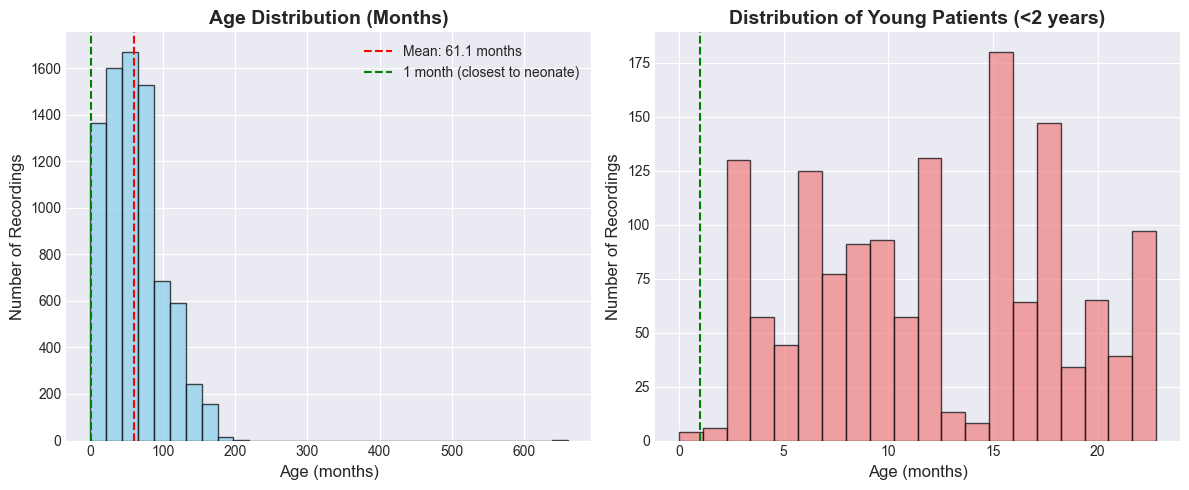

In [125]:
print("\n" + "="*60)
print("Visualization 1: Age Distribution")
print("="*60)

# Convert age from years to months for better interpretation
df_files['age_months'] = df_files['age'] * 12

print(f"Age in months - Min: {df_files['age_months'].min():.1f}, Max: {df_files['age_months'].max():.1f}, Mean: {df_files['age_months'].mean():.1f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_files['age_months'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Age Distribution (Months)', fontsize=14, fontweight='bold')
plt.xlabel('Age (months)', fontsize=12)
plt.ylabel('Number of Recordings', fontsize=12)
plt.axvline(df_files['age_months'].mean(), color='red', linestyle='--', 
            label=f"Mean: {df_files['age_months'].mean():.1f} months")
plt.axvline(1, color='green', linestyle='--', label="1 month (closest to neonate)")
plt.legend()

plt.subplot(1, 2, 2)
# Focus on youngest patients (under 2 years)
young_patients = df_files[df_files['age_months'] < 24]
plt.hist(young_patients['age_months'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
plt.title('Distribution of Young Patients (<2 years)', fontsize=14, fontweight='bold')
plt.xlabel('Age (months)', fontsize=12)
plt.ylabel('Number of Recordings', fontsize=12)
plt.axvline(1, color='green', linestyle='--', label="1 month")

plt.tight_layout()
plt.savefig(figures_dir / 'sprsound02_age_dist.png', dpi=150, bbox_inches='tight')
plt.show()

 ### Visualization 2: Gender Distribution


Visualization 2: Gender Distribution
gender
0    4277
1    3579
Name: count, dtype: int64


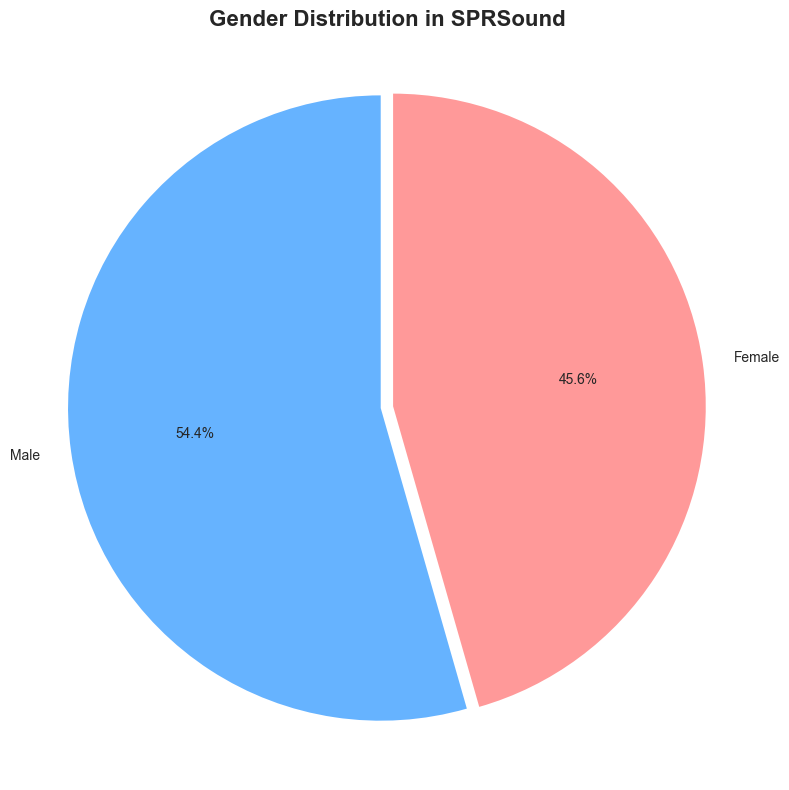

In [126]:
print("\n" + "="*60)
print("Visualization 2: Gender Distribution")
print("="*60)

gender_counts = df_files['gender'].value_counts()
print(gender_counts)

plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#ff9999']
plt.pie(gender_counts.values, labels=['Male', 'Female'], autopct='%1.1f%%',
        colors=colors, startangle=90, explode=[0.02, 0.02])
plt.title('Gender Distribution in SPRSound', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig(figures_dir / 'sprsound03_gender_pie.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 3: Recording Location Distribution


Visualization 3: Chest Location Distribution
location
p2    2039
p1    1977
p3    1961
p4    1879
Name: count, dtype: int64


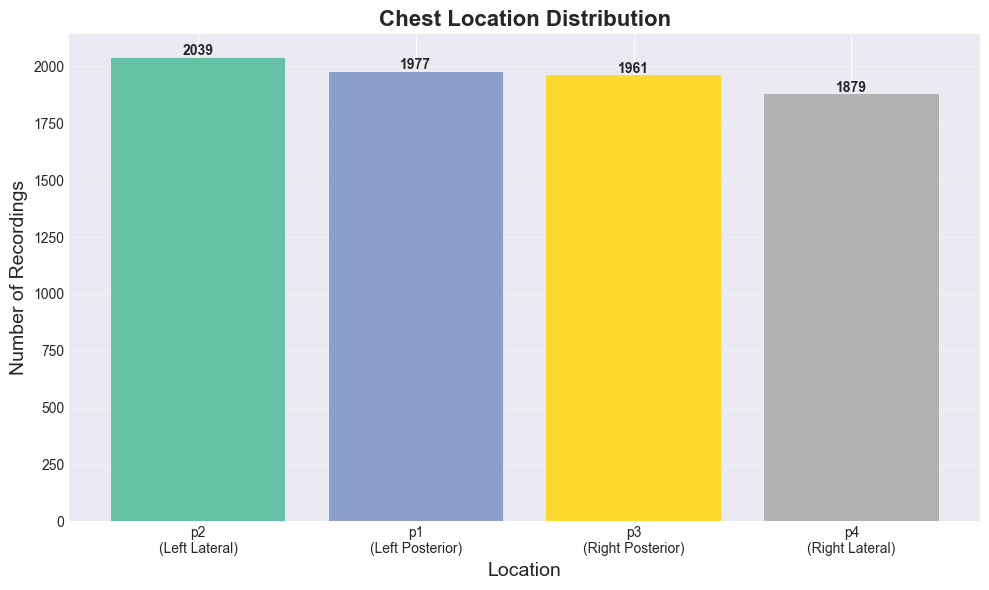

In [127]:
print("\n" + "="*60)
print("Visualization 3: Chest Location Distribution")
print("="*60)

location_counts = df_files['location'].value_counts()
print(location_counts)

# Decode location codes
location_names = {
    'p1': 'Left Posterior',
    'p2': 'Left Lateral', 
    'p3': 'Right Posterior',
    'p4': 'Right Lateral'
}

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(location_counts)), location_counts.values, 
               color=plt.cm.Set2(np.linspace(0, 1, len(location_counts))))
plt.title('Chest Location Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Location', fontsize=14)
plt.ylabel('Number of Recordings', fontsize=14)
plt.xticks(range(len(location_counts)), 
           [f"{code}\n({location_names.get(code, code)})" for code in location_counts.index])
plt.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, location_counts.values)):
    plt.text(i, val + 10, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'sprsound04_location_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Load and Parse JSON Annotations

In [128]:
def parse_sprsound_annotation(json_path):
    # Parse SPRSound JSON annotation file - handles string values
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        recording_label = data.get('recording_annotation', 'Unknown')
        
        events = []
        for event in data.get('event_annotation', []):
            # Convert start and end to float (they might be strings)
            start = event.get('start', 0)
            end = event.get('end', 0)
            
            # Convert to float if they're strings
            if isinstance(start, str):
                start = float(start)
            if isinstance(end, str):
                end = float(end)
            
            duration = end - start
            
            events.append({
                'annotation_file': json_path.name,
                'recording_file': json_path.stem + '.wav',
                'start_ms': start,
                'end_ms': end,
                'duration_ms': duration,
                'event_type': event.get('type', 'Unknown')
            })
        
        return recording_label, events
    except Exception as e:
        # Silent fail for EDA - just return empty
        return None, []

# Parse a sample of JSON files
print("\n" + "="*60)
print("Parsing JSON Annotations")
print("="*60)

# Take a sample of JSON files
sample_size = min(50, len(json_files))
sample_jsons = json_files[:sample_size]

all_events = []
recording_labels = []
success_count = 0

for json_path in sample_jsons:
    recording_label, events = parse_sprsound_annotation(json_path)
    if recording_label and len(events) > 0:
        recording_labels.append(recording_label)
        all_events.extend(events)
        success_count += 1

# Create DataFrame only if we have events
if len(all_events) > 0:
    df_events = pd.DataFrame(all_events)
    print(f"Successfully parsed {len(df_events)} events from {success_count} annotation files")
    print(f"\nEvent type distribution:")
    print(df_events['event_type'].value_counts())
else:
    df_events = pd.DataFrame()  # Empty DataFrame
    print(f"No events parsed from {sample_size} files. Using file-level labels only.")


Parsing JSON Annotations
Successfully parsed 133 events from 45 annotation files

Event type distribution:
event_type
Normal    130
Wheeze      3
Name: count, dtype: int64


## 8. Visualizations_2

### Visualization 4: Event-Level Labels


Visualization 4: Event-Level Label Distribution
event_type
Normal    130
Wheeze      3
Name: count, dtype: int64


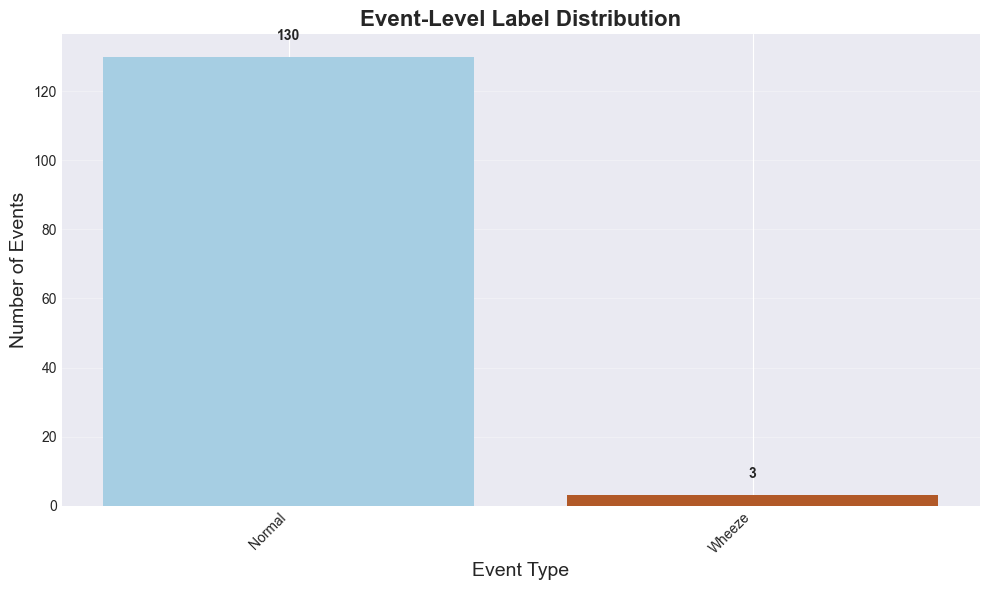

In [129]:
if len(df_events) > 0:
    print("\n" + "="*60)
    print("Visualization 4: Event-Level Label Distribution")
    print("="*60)
    
    event_counts = df_events['event_type'].value_counts()
    print(event_counts)
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(range(len(event_counts)), event_counts.values, 
                   color=plt.cm.Paired(np.linspace(0, 1, len(event_counts))))
    plt.title('Event-Level Label Distribution', fontsize=16, fontweight='bold')
    plt.xlabel('Event Type', fontsize=14)
    plt.ylabel('Number of Events', fontsize=14)
    plt.xticks(range(len(event_counts)), event_counts.index, rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    
    for i, (bar, val) in enumerate(zip(bars, event_counts.values)):
        plt.text(i, val + 5, str(val), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'sprsound06_event_labels.png', dpi=150, bbox_inches='tight')
    plt.show()

### Symptom Mapping

In [130]:
if len(df_events) > 0:
    print("\n" + "="*60)
    print("Creating Symptom Labels from Events")
    print("="*60)
    
    # Map event types to symptom classes
    SYMPTOM_CLASSES = {
        'wheeze': 'Wheeze',
        'crackle': 'Crackles', 
        'rhonchi': 'Rhonchi',
        'stridor': 'Stridor',
        'normal': 'Normal',
        'coarse crackle': 'Crackles',
        'fine crackle': 'Crackles',
        'wheeze+crackle': 'Wheeze+Crackle'
    }
    
    # Create symptom class for each event - FIXED: using correct column name
    df_events['symptom_class'] = df_events['event_type'].str.lower().map(
        lambda x: next((v for k, v in SYMPTOM_CLASSES.items() if k in x), 'Other')
    )
    
    # Check if 'recording_file' column exists (it should from the parsing function)
    if 'recording_file' in df_events.columns:
        # Create recording-level labels (multi-label for mixed symptoms)
        recording_symptoms = df_events.groupby('recording_file')['symptom_class'].agg(
            lambda x: ' & '.join(sorted(set(x))) if len(set(x)) > 1 else list(x)[0]
        ).reset_index()
        recording_symptoms.columns = ['recording_file', 'combined_symptom']
        
        print(f"Created labels for {len(recording_symptoms)} recordings")
        print("\nSymptom distribution at recording level:")
        print(recording_symptoms['combined_symptom'].value_counts())
    else:
        print("'recording_file' column not found. Available columns:")
        print(df_events.columns.tolist())
else:
    print("No event data available for symptom labeling")


Creating Symptom Labels from Events
Created labels for 45 recordings

Symptom distribution at recording level:
combined_symptom
Normal             44
Normal & Wheeze     1
Name: count, dtype: int64


### Visualization 5: Event Duration Distribution


Visualization 5: Event Duration Distribution


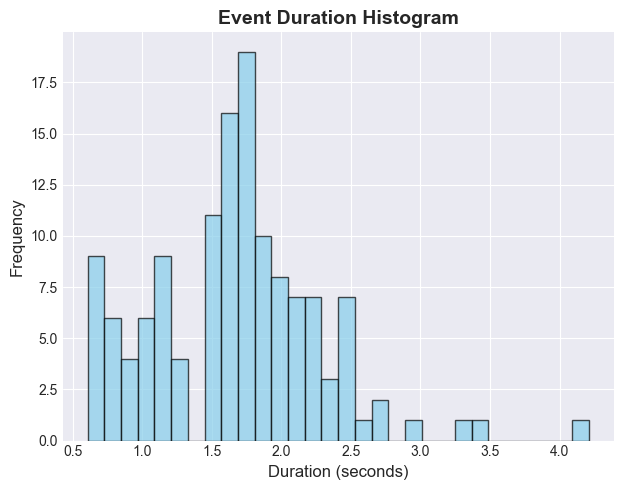

In [131]:
if len(df_events) > 0:
    print("\n" + "="*60)
    print("Visualization 5: Event Duration Distribution")
    print("="*60)
    
    # Convert ms to seconds
    df_events['duration_sec'] = df_events['duration_ms'] / 1000
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(df_events['duration_sec'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title('Event Duration Histogram', fontsize=14, fontweight='bold')
    plt.xlabel('Duration (seconds)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'sprsound07_event_durations.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Audio Analysis Functions

In [132]:
def extract_audio_features(file_path):
    # Extract basic audio features from a WAV file
    try:
        y, sr = librosa.load(file_path, sr=None)
        duration = len(y) / sr
        
        features = {
            'file': file_path.name,
            'duration': duration,
            'sample_rate': sr,
            'samples': len(y),
            'rms_mean': np.mean(librosa.feature.rms(y=y)),
            'zcr_mean': np.mean(librosa.feature.zero_crossing_rate(y)),
            'spectral_centroid': np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        }
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            features[f'mfcc_{i+1}'] = np.mean(mfccs[i])
            
        return features, y, sr
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None, None

# Extract features from a sample of audio files
sample_wavs = wav_files[:50]
audio_features = []
for f in sample_wavs:
    features, _, _ = extract_audio_features(f)
    if features:
        audio_features.append(features)

df_audio = pd.DataFrame(audio_features)
print(f"Extracted features from {len(df_audio)} files")

Extracted features from 50 files


## 10. Visualizations_3

 ### Visualization 6: Duration Distribution


Visualization 6: Duration Distribution


<Figure size 1200x600 with 0 Axes>

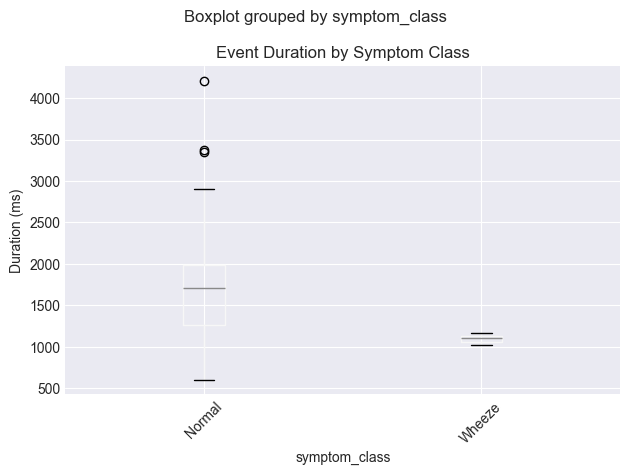

In [133]:
print("\n" + "="*60)
print("Visualization 6: Duration Distribution")
print("="*60)


# Analyze event durations by symptom class
if len(df_events) > 0:
    plt.figure(figsize=(12, 6))
    df_events.boxplot(column='duration_ms', by='symptom_class')
    plt.title('Event Duration by Symptom Class')
    plt.ylabel('Duration (ms)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(figures_dir / 'sprsound01_duration_by_symptom.png', dpi=150, bbox_inches='tight')
    plt.show()

### Visualization 7: Sample Waveforms by Age Group


Visualization 7: Sample Waveforms by Age Group


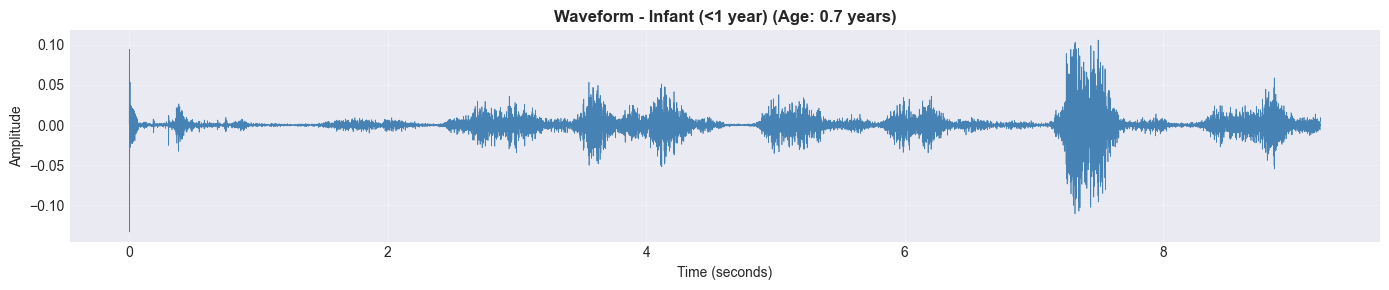

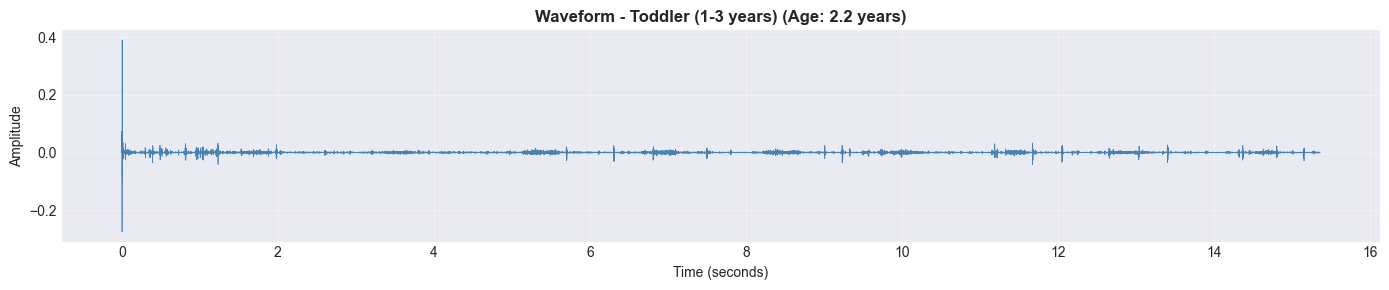

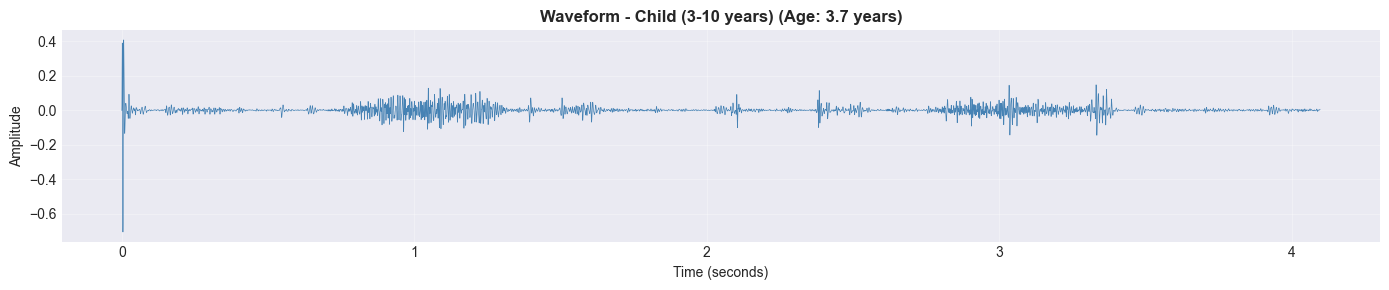

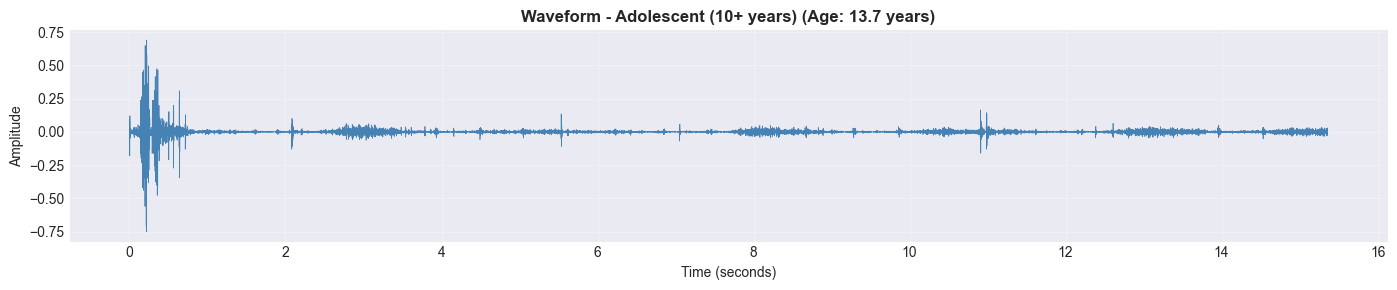

In [134]:
print("\n" + "="*60)
print("Visualization 7: Sample Waveforms by Age Group")
print("="*60)

age_groups = [
    ('Infant (<1 year)', df_files[df_files['age'] < 1]),
    ('Toddler (1-3 years)', df_files[(df_files['age'] >= 1) & (df_files['age'] < 3)]),
    ('Child (3-10 years)', df_files[(df_files['age'] >= 3) & (df_files['age'] < 10)]),
    ('Adolescent (10+ years)', df_files[df_files['age'] >= 10])
]

for group_name, group_df in age_groups:
    if len(group_df) > 0:
        # Pick a random file from this group
        sample = group_df.sample(1).iloc[0]
        file_path = Path(sample['full_path'])
        
        if file_path.exists():
            y, sr = librosa.load(file_path, sr=None)
            
            plt.figure(figsize=(14, 3))
            times = np.linspace(0, len(y)/sr, len(y))
            plt.plot(times, y, color='steelblue', linewidth=0.5)
            plt.title(f'Waveform - {group_name} (Age: {sample["age"]:.1f} years)', 
                     fontsize=12, fontweight='bold')
            plt.xlabel('Time (seconds)')
            plt.ylabel('Amplitude')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(figures_dir / f'sprsound09_waveform_{group_name.replace(" ", "_").replace("<", "under")}.png', 
                       dpi=150, bbox_inches='tight')
            plt.show()

### Visualization 8: MFCC Heatmap by Age Group


Visualization 8: MFCC Comparison by Age


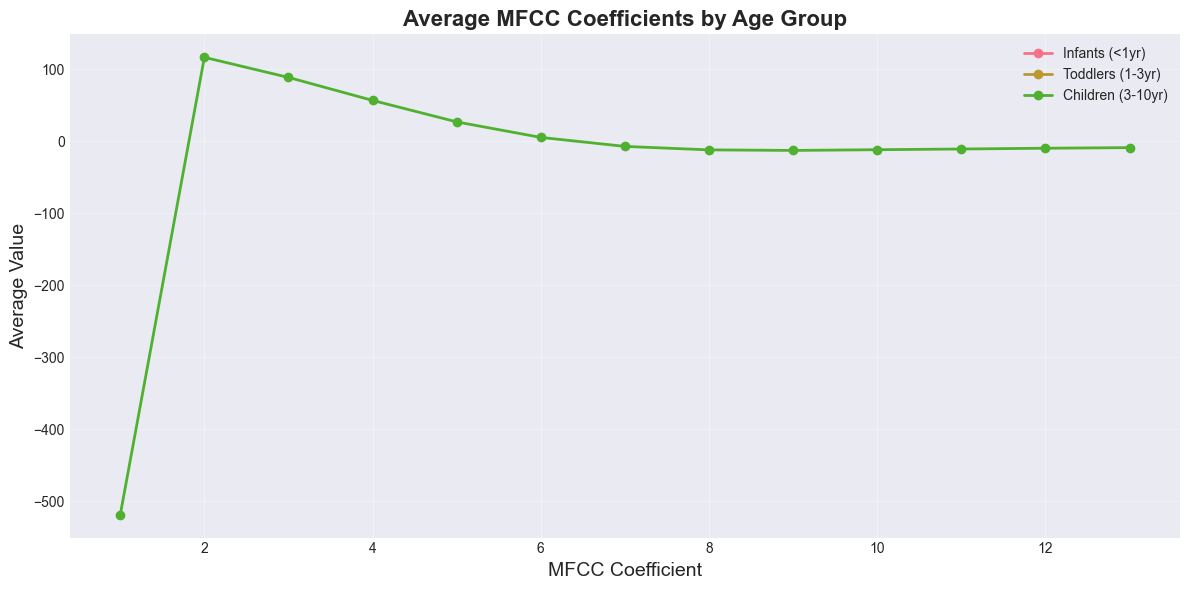

In [135]:
if len(df_audio) > 0 and len(df_files) > 0:
    print("\n" + "="*60)
    print("Visualization 8: MFCC Comparison by Age")
    print("="*60)
    
    # Merge audio features with metadata
    df_merged = pd.merge(df_audio, df_files, left_on='file', right_on='filename')
    
    # Group by age group
    age_groups = []
    mfcc_cols = [f'mfcc_{i+1}' for i in range(13)]
    
    for group_name, condition in [
        ('Infants (<1yr)', df_merged['age'] < 1),
        ('Toddlers (1-3yr)', (df_merged['age'] >= 1) & (df_merged['age'] < 3)),
        ('Children (3-10yr)', (df_merged['age'] >= 3) & (df_merged['age'] < 10))
    ]:
        group_data = df_merged[condition][mfcc_cols].mean().values
        if len(group_data) > 0:
            age_groups.append((group_name, group_data))
    
    if age_groups:
        plt.figure(figsize=(12, 6))
        for group_name, mfcc_vals in age_groups:
            plt.plot(range(1, 14), mfcc_vals, marker='o', linewidth=2, label=group_name)
        
        plt.title('Average MFCC Coefficients by Age Group', fontsize=16, fontweight='bold')
        plt.xlabel('MFCC Coefficient', fontsize=14)
        plt.ylabel('Average Value', fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(figures_dir / 'sprsound10_mfcc_by_age.png', dpi=150, bbox_inches='tight')
        plt.show()

### Visualization 9: Train/Test Split Distribution


Visualization 9: Train/Test Split Distribution
split
test     4228
train    3628
Name: count, dtype: int64


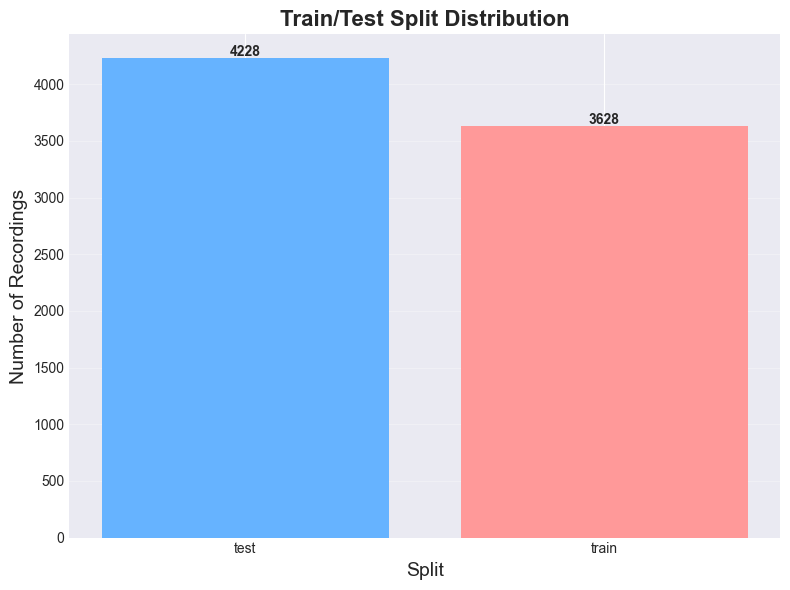

In [136]:
print("\n" + "="*60)
print("Visualization 9: Train/Test Split Distribution")
print("="*60)

split_counts = df_files['split'].value_counts()
print(split_counts)

plt.figure(figsize=(8, 6))
bars = plt.bar(range(len(split_counts)), split_counts.values, 
               color=['#66b3ff', '#ff9999'])
plt.title('Train/Test Split Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Split', fontsize=14)
plt.ylabel('Number of Recordings', fontsize=14)
plt.xticks(range(len(split_counts)), split_counts.index)
plt.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, split_counts.values)):
    plt.text(i, val + 20, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'sprsound11_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 10: Average Signal Envelope by Age Group


Visualization 10: Average Signal Envelope (Loudness) Over Time by Age Group


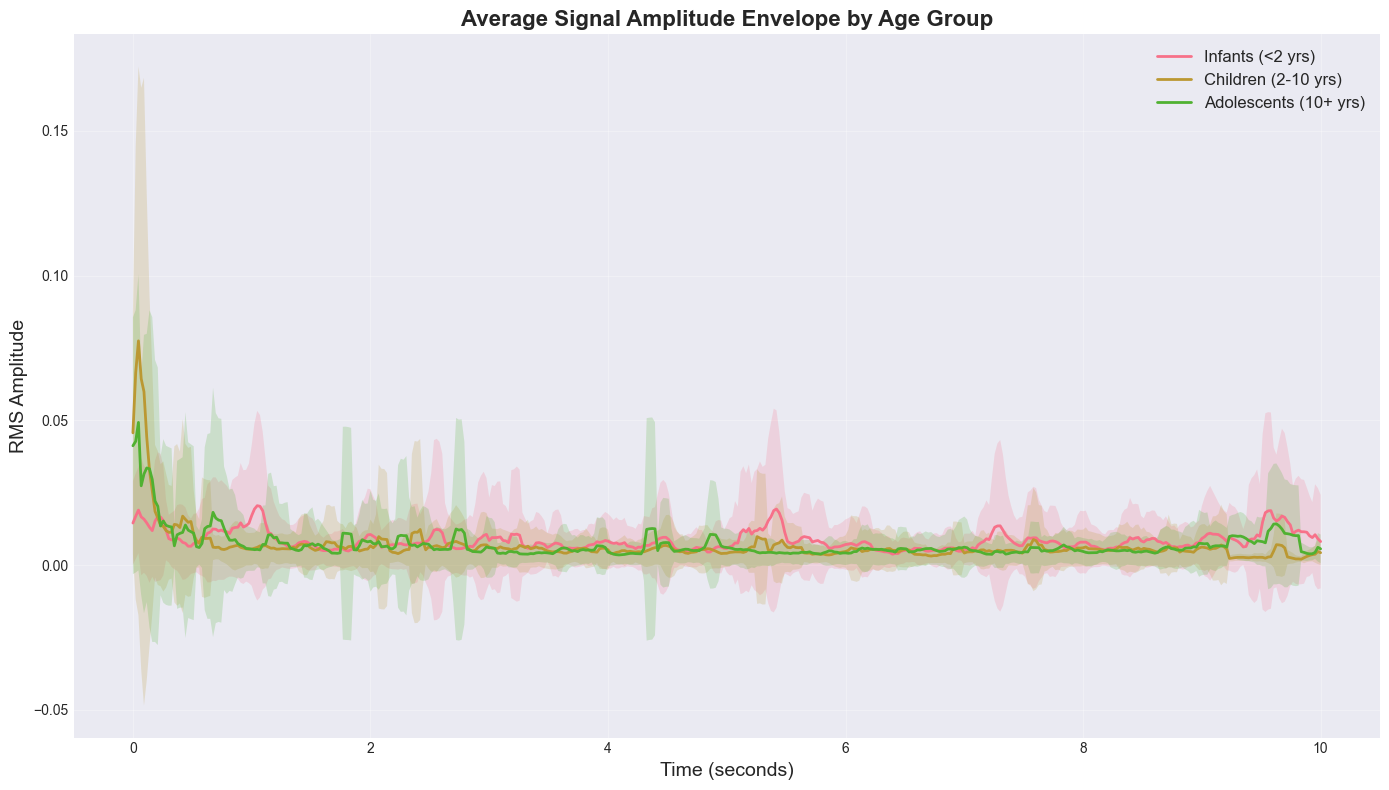

In [137]:
print("\n" + "="*60)
print("Visualization 10: Average Signal Envelope (Loudness) Over Time by Age Group")
print("="*60)

def extract_envelope(file_path, duration=10):
    # Extract amplitude envelope from audio file
    try:
        y, sr = librosa.load(file_path, sr=22050, duration=duration)
        # Compute RMS envelope with hop_length to reduce dimensionality
        hop_length = 512
        rms = librosa.feature.rms(y=y, hop_length=hop_length)[0]
        times = librosa.frames_to_time(range(len(rms)), sr=sr, hop_length=hop_length)
        return times, rms
    except Exception as e:
        return None, None

# Group files by age group
age_groups = {
    'Infants (<2 yrs)': df_files[df_files['age'] < 2].sample(min(30, len(df_files[df_files['age'] < 2]))),
    'Children (2-10 yrs)': df_files[(df_files['age'] >= 2) & (df_files['age'] < 10)].sample(min(30, len(df_files[(df_files['age'] >= 2) & (df_files['age'] < 10)]))),
    'Adolescents (10+ yrs)': df_files[df_files['age'] >= 10].sample(min(30, len(df_files[df_files['age'] >= 10])))
}

plt.figure(figsize=(14, 8))

for group_name, group_df in age_groups.items():
    if len(group_df) > 0:
        all_envelopes = []
        max_len = 0
        
        for _, row in group_df.iterrows():
            file_path = Path(row['full_path'])
            if file_path.exists():
                times, envelope = extract_envelope(file_path)
                if envelope is not None:
                    # Normalize length to 10 seconds
                    if len(envelope) > max_len:
                        max_len = len(envelope)
                    all_envelopes.append(envelope)
        
        if all_envelopes:
            # Pad all envelopes to same length
            padded_envelopes = [np.pad(e, (0, max_len - len(e)), 'constant', constant_values=np.nan) 
                              for e in all_envelopes]
            mean_envelope = np.nanmean(padded_envelopes, axis=0)
            std_envelope = np.nanstd(padded_envelopes, axis=0)
            
            # Create time axis
            time_axis = np.linspace(0, 10, len(mean_envelope))
            
            # Plot mean with confidence band
            plt.plot(time_axis, mean_envelope, linewidth=2, label=group_name)
            plt.fill_between(time_axis, 
                            mean_envelope - std_envelope, 
                            mean_envelope + std_envelope, 
                            alpha=0.2)

plt.title('Average Signal Amplitude Envelope by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=14)
plt.ylabel('RMS Amplitude', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'sprsound12_envelope_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

###  Visualization 11: Zero-Crossing Rate by Symptom Class

In [138]:
print("\n" + "="*60)
print("Visualization 11: Zero-Crossing Rate Distribution by Symptom Class")
print("="*60)

if len(df_events) > 0 and len(df_audio) > 0:
    # Merge audio features with events
    df_audio_with_labels = pd.merge(
        df_audio, 
        df_events[['recording_file', 'symptom_class']].drop_duplicates(),
        left_on='file', 
        right_on='recording_file',
        how='inner'
    )
    
    if len(df_audio_with_labels) > 0:
        plt.figure(figsize=(14, 8))
        
        # Create violin plot with swarm plot overlay
        ax = sns.violinplot(data=df_audio_with_labels, x='symptom_class', y='zcr_mean', 
                            palette='Set2', inner=None, alpha=0.6)
        sns.swarmplot(data=df_audio_with_labels, x='symptom_class', y='zcr_mean', 
                     color='black', size=4, alpha=0.6)
        
        plt.title('Zero-Crossing Rate Distribution by Symptom Class', fontsize=16, fontweight='bold')
        plt.xlabel('Symptom Class', fontsize=14)
        plt.ylabel('Zero-Crossing Rate', fontsize=14)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(figures_dir / 'sprsound13_zcr_by_symptom.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Print statistics
        print("\nZCR Statistics by Symptom Class:")
        print(df_audio_with_labels.groupby('symptom_class')['zcr_mean'].describe())
else:
    print("Need both event labels and audio features for this visualization")


Visualization 11: Zero-Crossing Rate Distribution by Symptom Class


### Visualization 12: UMAP Projection of Audio Features


Visualization 12 UMAP Projection of Audio Features


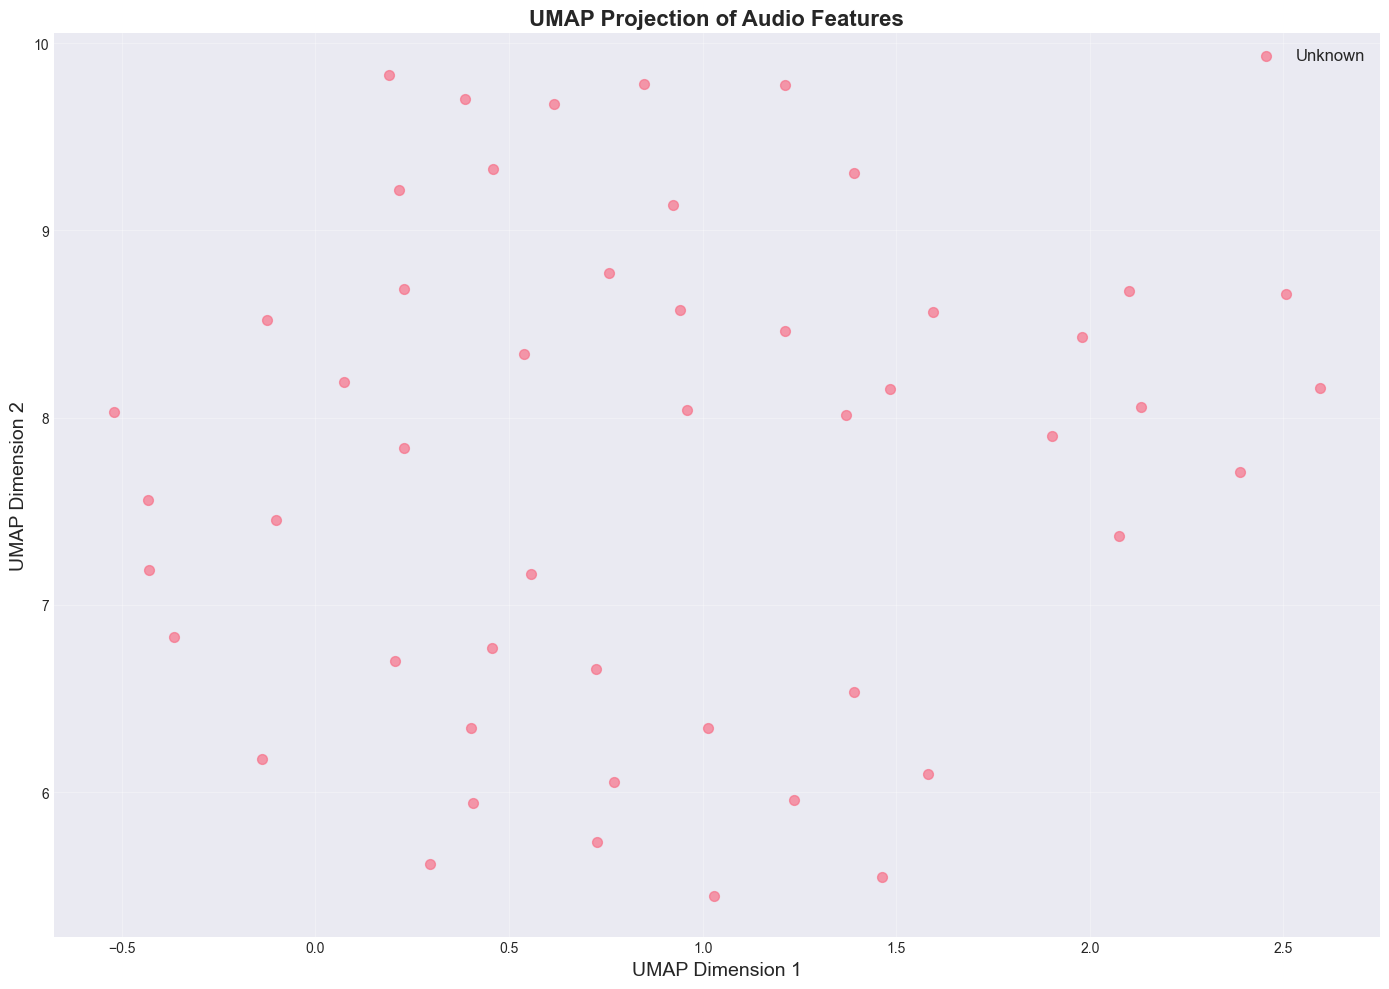

UMAP projection created from 50 recordings with 16 features


In [139]:
print("\n" + "="*60)
print("Visualization 12 UMAP Projection of Audio Features")
print("="*60)

if len(df_audio) > 10:  # Need enough samples
    # Prepare features
    feature_cols = ['rms_mean', 'zcr_mean', 'spectral_centroid'] + [f'mfcc_{i+1}' for i in range(13)]
    feature_cols = [col for col in feature_cols if col in df_audio.columns]
    
    X = df_audio[feature_cols].values
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply UMAP
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    
    # Create plot
    plt.figure(figsize=(14, 10))
    
    # Try to color by event type if available
    if len(df_events) > 0 and 'recording_file' in df_events.columns:
        # Merge UMAP results with event labels
        umap_df = pd.DataFrame({
            'UMAP1': X_umap[:, 0],
            'UMAP2': X_umap[:, 1],
            'file': df_audio['file']
        })
        
        # Get primary event type per recording
        event_types = df_events.groupby('recording_file')['symptom_class'].first().reset_index()
        umap_df = pd.merge(umap_df, event_types, left_on='file', right_on='recording_file', how='left')
        umap_df['symptom_class'] = umap_df['symptom_class'].fillna('Unknown')
        
        # Plot with colors
        for symptom in umap_df['symptom_class'].unique():
            mask = umap_df['symptom_class'] == symptom
            plt.scatter(umap_df.loc[mask, 'UMAP1'], umap_df.loc[mask, 'UMAP2'], 
                       label=symptom, alpha=0.7, s=50)
    else:
        plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.6, s=30, c='steelblue')
    
    plt.title('UMAP Projection of Audio Features', fontsize=16, fontweight='bold')
    plt.xlabel('UMAP Dimension 1', fontsize=14)
    plt.ylabel('UMAP Dimension 2', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(figures_dir / 'sprsound16_umap_projection.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"UMAP projection created from {len(df_audio)} recordings with {len(feature_cols)} features")
else:
    print("Need at least 10 audio files with features for UMAP")

### Visualization 13: Spectral Centroid Distribution by Symptom Class

In [140]:
print("\n" + "="*60)
print("Visualization 13: Spectral Centroid Distribution by Symptom Class")
print("="*60)

if len(df_events) > 0 and len(df_audio) > 0:
    # Merge audio features with events
    df_audio_with_labels = pd.merge(
        df_audio, 
        df_events[['recording_file', 'symptom_class']].drop_duplicates(),
        left_on='file', 
        right_on='recording_file',
        how='inner'
    )
    
    if len(df_audio_with_labels) > 0:
        plt.figure(figsize=(14, 8))
        
        # Create raincloud plot (half-violin + boxplot + points)
        # First, create violin plot
        sns.violinplot(data=df_audio_with_labels, x='symptom_class', y='spectral_centroid',
                      palette='Set2', cut=0, inner=None, alpha=0.6)
        
        # Add boxplot
        sns.boxplot(data=df_audio_with_labels, x='symptom_class', y='spectral_centroid',
                   width=0.2, showfliers=False, boxprops={'alpha': 0.8})
        
        # Add strip plot for individual points
        sns.stripplot(data=df_audio_with_labels, x='symptom_class', y='spectral_centroid',
                     color='black', size=4, alpha=0.5, jitter=0.2)
        
        plt.title('Spectral Centroid Distribution by Symptom Class', fontsize=16, fontweight='bold')
        plt.xlabel('Symptom Class', fontsize=14)
        plt.ylabel('Spectral Centroid (Hz)', fontsize=14)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(figures_dir / 'sprsound18_spectral_centroid_by_symptom.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Print statistics
        print("\nSpectral Centroid Statistics by Symptom Class:")
        print(df_audio_with_labels.groupby('symptom_class')['spectral_centroid'].describe())
else:
    print("Need both event labels and audio features for this visualization")


Visualization 13: Spectral Centroid Distribution by Symptom Class


### Visualization 14: Correlation Matrix of Audio Features


Visualization 14: Correlation Matrix of Audio Features


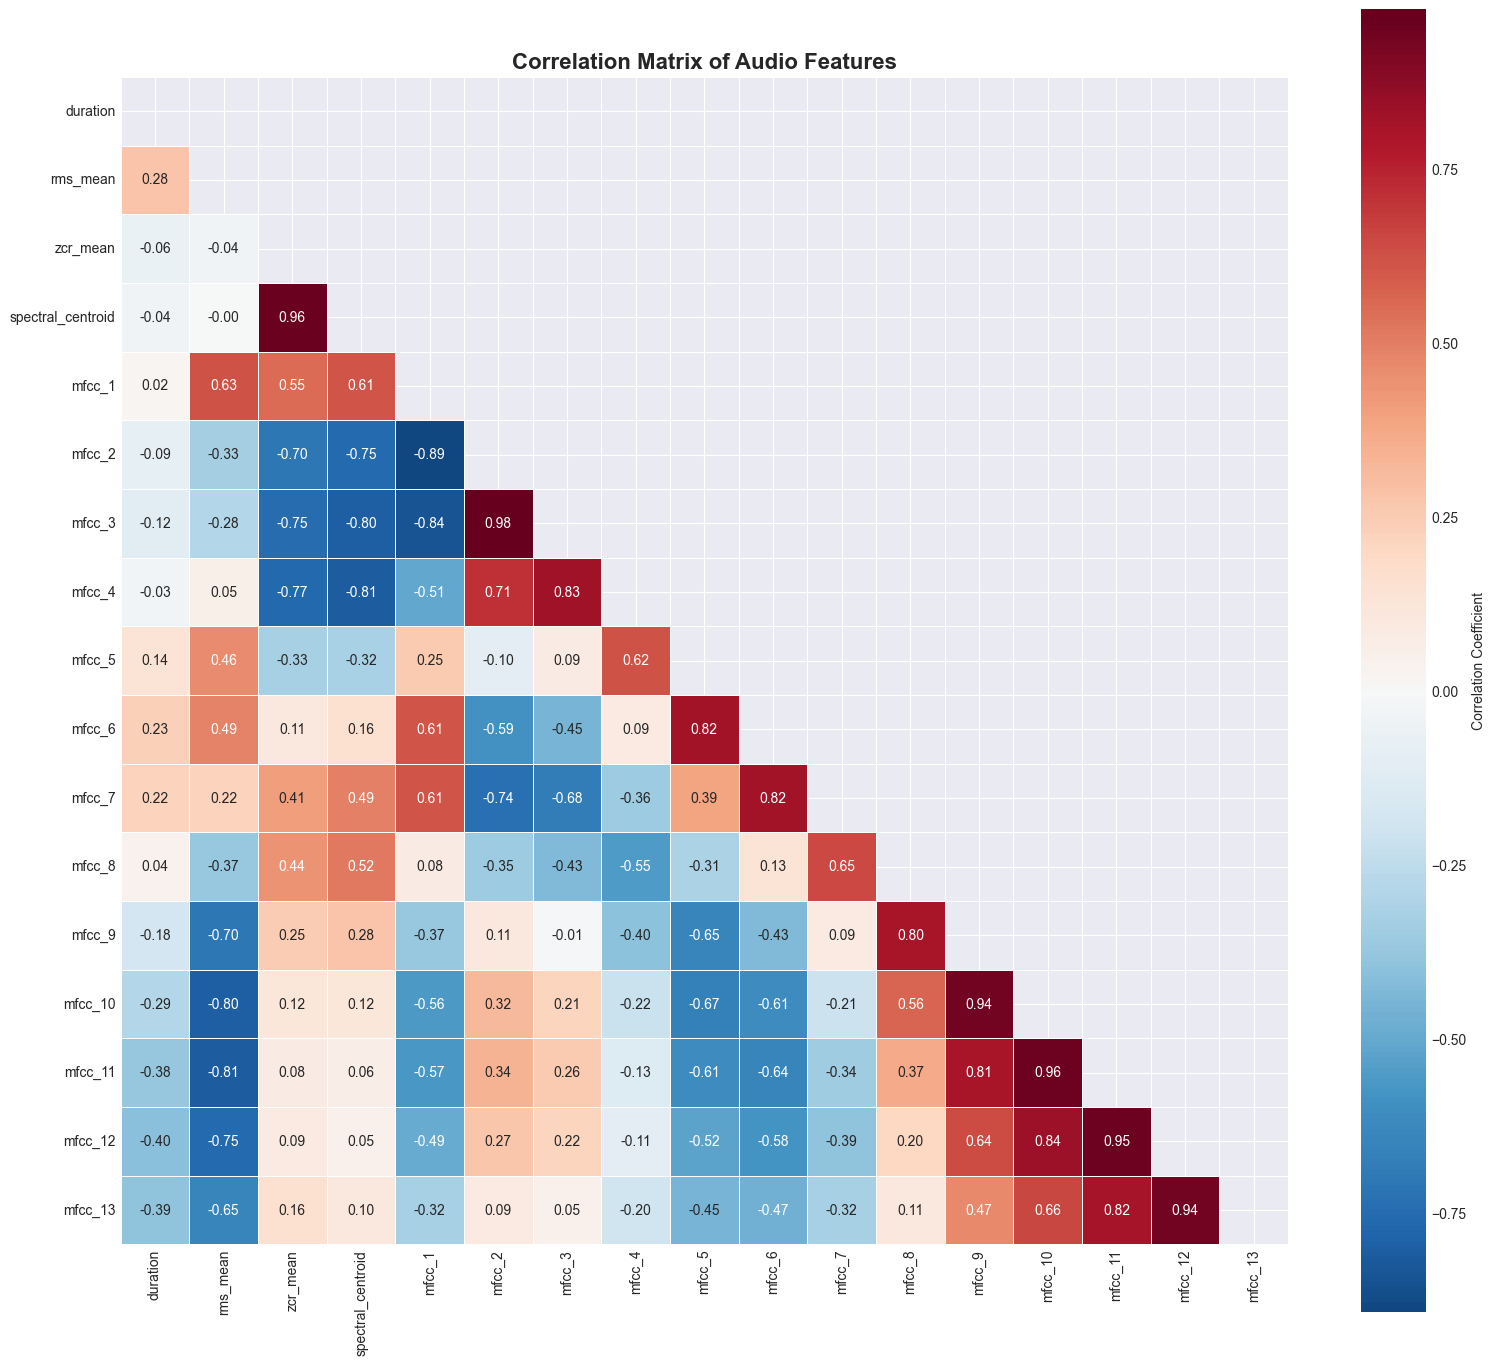


Highly Correlated Feature Pairs (|r| > 0.8):
  spectral_centroid ↔ zcr_mean: 0.960
  mfcc_2 ↔ mfcc_1: -0.892
  mfcc_3 ↔ mfcc_1: -0.841
  mfcc_3 ↔ mfcc_2: 0.979
  mfcc_4 ↔ spectral_centroid: -0.809
  mfcc_4 ↔ mfcc_3: 0.831
  mfcc_6 ↔ mfcc_5: 0.823
  mfcc_7 ↔ mfcc_6: 0.822
  mfcc_9 ↔ mfcc_8: 0.805
  mfcc_10 ↔ mfcc_9: 0.936
  mfcc_11 ↔ rms_mean: -0.805
  mfcc_11 ↔ mfcc_9: 0.810
  mfcc_11 ↔ mfcc_10: 0.956
  mfcc_12 ↔ mfcc_10: 0.835
  mfcc_12 ↔ mfcc_11: 0.953
  mfcc_13 ↔ mfcc_11: 0.816
  mfcc_13 ↔ mfcc_12: 0.941


In [141]:
print("\n" + "="*60)
print("Visualization 14: Correlation Matrix of Audio Features")
print("="*60)

if len(df_audio) > 0:
    # Select numeric features
    feature_cols = ['duration', 'rms_mean', 'zcr_mean', 'spectral_centroid'] + [f'mfcc_{i+1}' for i in range(13)]
    feature_cols = [col for col in feature_cols if col in df_audio.columns]
    
    # Calculate correlation matrix
    corr_matrix = df_audio[feature_cols].corr()
    
    plt.figure(figsize=(16, 14))
    
    # Create heatmap
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
               square=True, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
    
    plt.title('Correlation Matrix of Audio Features', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(figures_dir / 'sprsound19_feature_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Find highly correlated features
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr = [(col, upper[col][(upper[col] > 0.8) | (upper[col] < -0.8)].index.tolist()) 
                 for col in upper.columns if len(upper[col][(upper[col] > 0.8) | (upper[col] < -0.8)]) > 0]
    
    print("\nHighly Correlated Feature Pairs (|r| > 0.8):")
    for col, correlated in high_corr:
        for corr_col in correlated:
            corr_val = corr_matrix.loc[col, corr_col]
            print(f"  {col} ↔ {corr_col}: {corr_val:.3f}")
else:
    print("Need audio features for correlation analysis")

### Visualization 15: Wavelet Scalogram Comparison (Normal vs. Wheeze)


Visualization 15: Wavelet Scalogram Comparison (Normal vs. Wheeze)


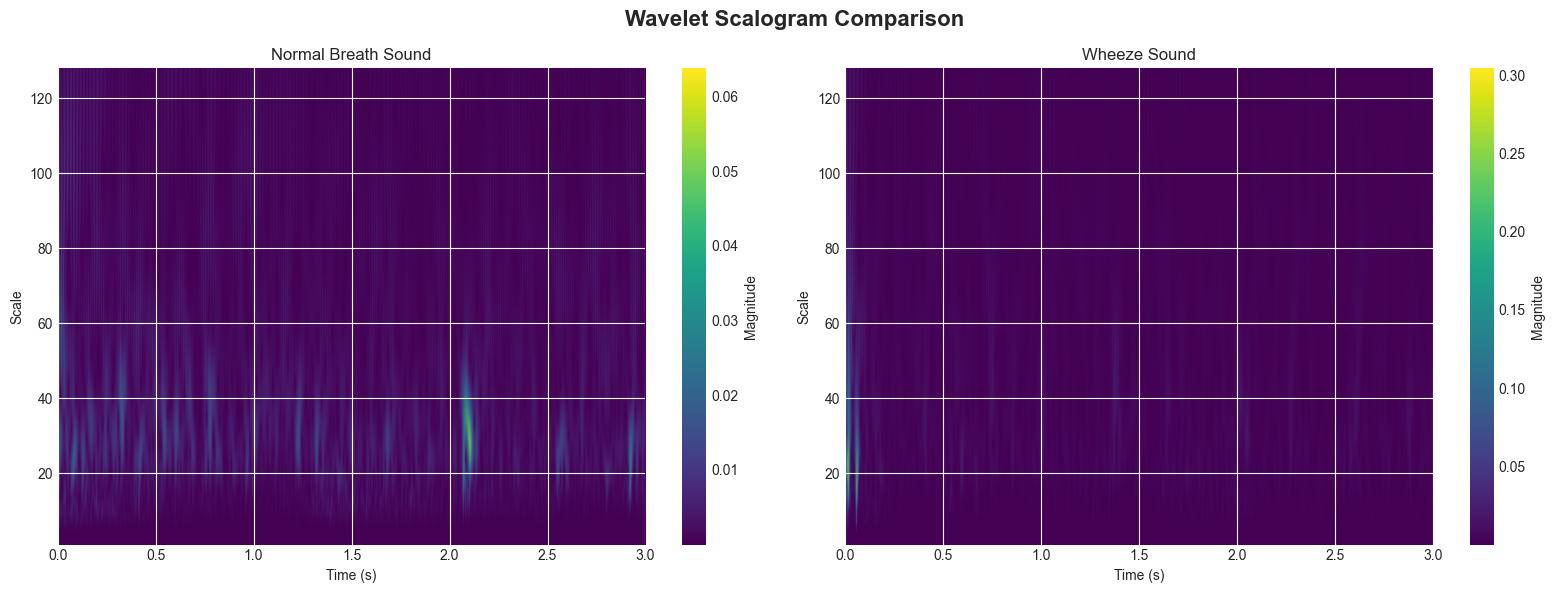

In [142]:
print("\n" + "="*60)
print("Visualization 15: Wavelet Scalogram Comparison (Normal vs. Wheeze)")
print("="*60)

def plot_wavelet_scalogram(y, sr, title, ax):
    # Plot wavelet scalogram
    # Select a wavelet
    wavelet = 'morl'
    scales = np.arange(1, 128)
    
    # Compute continuous wavelet transform
    coefficients, frequencies = pywt.cwt(y[:min(len(y), sr*5)], scales, wavelet, sampling_period=1/sr)
    
    # Plot scalogram
    extent = [0, len(y)/sr, 1, 128]
    im = ax.imshow(np.abs(coefficients), extent=extent, cmap='viridis', 
                  aspect='auto', origin='lower')
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Scale')
    return im

if len(df_events) > 0 and 'event_type' in df_events.columns:
    # Find one normal and one wheeze recording
    normal_files = df_events[df_events['event_type'].str.contains('Normal', case=False, na=False)]['recording_file'].unique()
    wheeze_files = df_events[df_events['event_type'].str.contains('Wheeze', case=False, na=False)]['recording_file'].unique()
    
    if len(normal_files) > 0 and len(wheeze_files) > 0:
        # Get full paths
        normal_path = None
        wheeze_path = None
        
        for _, row in df_files.iterrows():
            if row['filename'] in normal_files and normal_path is None:
                normal_path = Path(row['full_path'])
            if row['filename'] in wheeze_files and wheeze_path is None:
                wheeze_path = Path(row['full_path'])
        
        if normal_path and normal_path.exists() and wheeze_path and wheeze_path.exists():
            # Load audio
            y_normal, sr_normal = librosa.load(normal_path, sr=4000, duration=3)
            y_wheeze, sr_wheeze = librosa.load(wheeze_path, sr=4000, duration=3)
            
            # Create figure
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
            
            # Plot scalograms
            im1 = plot_wavelet_scalogram(y_normal, sr_normal, 'Normal Breath Sound', ax1)
            im2 = plot_wavelet_scalogram(y_wheeze, sr_wheeze, 'Wheeze Sound', ax2)
            
            # Add colorbar
            plt.colorbar(im1, ax=ax1, label='Magnitude')
            plt.colorbar(im2, ax=ax2, label='Magnitude')
            
            plt.suptitle('Wavelet Scalogram Comparison', fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.savefig(figures_dir / 'sprsound20_wavelet_comparison.png', dpi=150, bbox_inches='tight')
            plt.show()
        else:
            print("Could not find audio files for selected recordings")
    else:
        print("Need both normal and wheeze recordings")
else:
    print("Need event data with Normal and Wheeze labels")

### Visualization 16: Silence/Voice Activity Distribution


Visualization 16: Voice Activity Distribution


Analyzing voice activity: 100%|██████████| 100/100 [00:00<00:00, 155.17it/s]


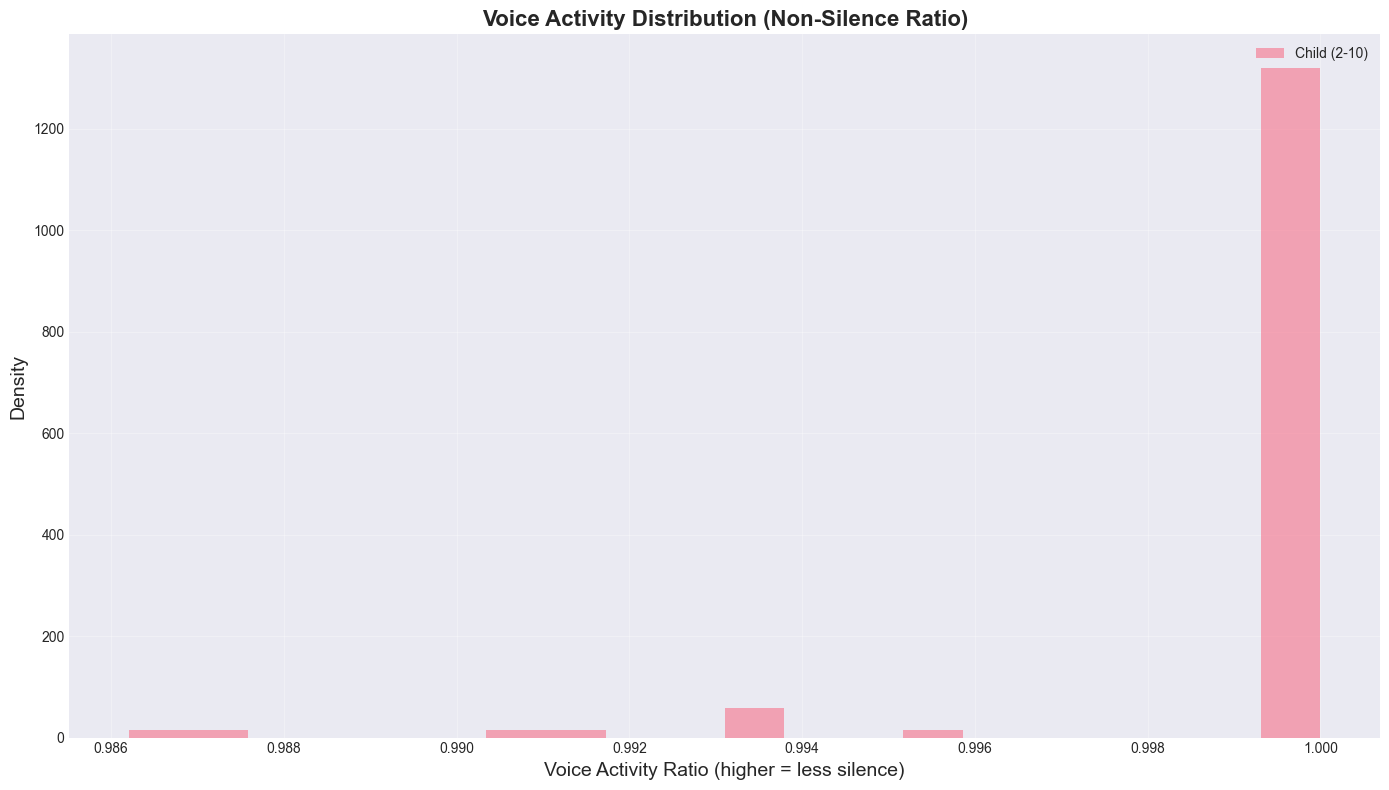


Voice Activity Statistics:
Mean: 0.999
Median: 1.000
Std: 0.003
Min: 0.986
Max: 1.000


In [143]:
print("\n" + "="*60)
print("Visualization 16: Voice Activity Distribution")
print("="*60)

def calculate_voice_activity_ratio(file_path, threshold_db=-40):
    # Calculate ratio of non-silent frames
    try:
        y, sr = librosa.load(file_path, sr=None)
        
        # Split into frames
        frame_length = 2048
        hop_length = 512
        
        # Calculate RMS energy
        rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
        
        # Convert to dB
        rms_db = librosa.amplitude_to_db(rms, ref=np.max)
        
        # Count frames above threshold
        active_frames = np.sum(rms_db > threshold_db)
        total_frames = len(rms_db)
        
        return active_frames / total_frames if total_frames > 0 else 0
    except Exception as e:
        return None

if len(wav_files) > 0:
    # Sample files for analysis
    sample_size = min(100, len(wav_files))
    sample_files = wav_files[:sample_size]
    
    voice_activity = []
    
    for file_path in tqdm(sample_files, desc="Analyzing voice activity"):
        ratio = calculate_voice_activity_ratio(file_path)
        if ratio is not None:
            voice_activity.append({
                'file': file_path.name,
                'voice_activity_ratio': ratio
            })
    
    if voice_activity:
        df_voice = pd.DataFrame(voice_activity)
        
        # Merge with metadata if available
        if 'df_files' in locals():
            df_voice = pd.merge(
                df_voice,
                df_files[['filename', 'age', 'gender', 'split']],
                left_on='file',
                right_on='filename',
                how='left'
            )
            
            # Create age groups
            df_voice['age_group'] = pd.cut(df_voice['age'], 
                                           bins=[0, 2, 10, 20, 100], 
                                           labels=['Infant (<2)', 'Child (2-10)', 
                                                  'Adolescent (10-20)', 'Adult (20+)'])
        
        plt.figure(figsize=(14, 8))
        
        # Plot histogram
        if 'age_group' in df_voice.columns:
            # Multiple histograms by age group
            for age_group in df_voice['age_group'].dropna().unique():
                subset = df_voice[df_voice['age_group'] == age_group]['voice_activity_ratio']
                plt.hist(subset, bins=20, alpha=0.6, label=age_group, density=True)
            plt.legend()
        else:
            plt.hist(df_voice['voice_activity_ratio'], bins=30, color='steelblue', 
                    edgecolor='black', alpha=0.7)
        
        plt.title('Voice Activity Distribution (Non-Silence Ratio)', fontsize=16, fontweight='bold')
        plt.xlabel('Voice Activity Ratio (higher = less silence)', fontsize=14)
        plt.ylabel('Density', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(figures_dir / 'sprsound21_voice_activity.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"\nVoice Activity Statistics:")
        print(f"Mean: {df_voice['voice_activity_ratio'].mean():.3f}")
        print(f"Median: {df_voice['voice_activity_ratio'].median():.3f}")
        print(f"Std: {df_voice['voice_activity_ratio'].std():.3f}")
        print(f"Min: {df_voice['voice_activity_ratio'].min():.3f}")
        print(f"Max: {df_voice['voice_activity_ratio'].max():.3f}")
else:
    print("Need audio files for analysis")

### Visualization 17: Top Patients by Number of Recordings


Visualization 17: Top 10 Patients by Number of Recordings


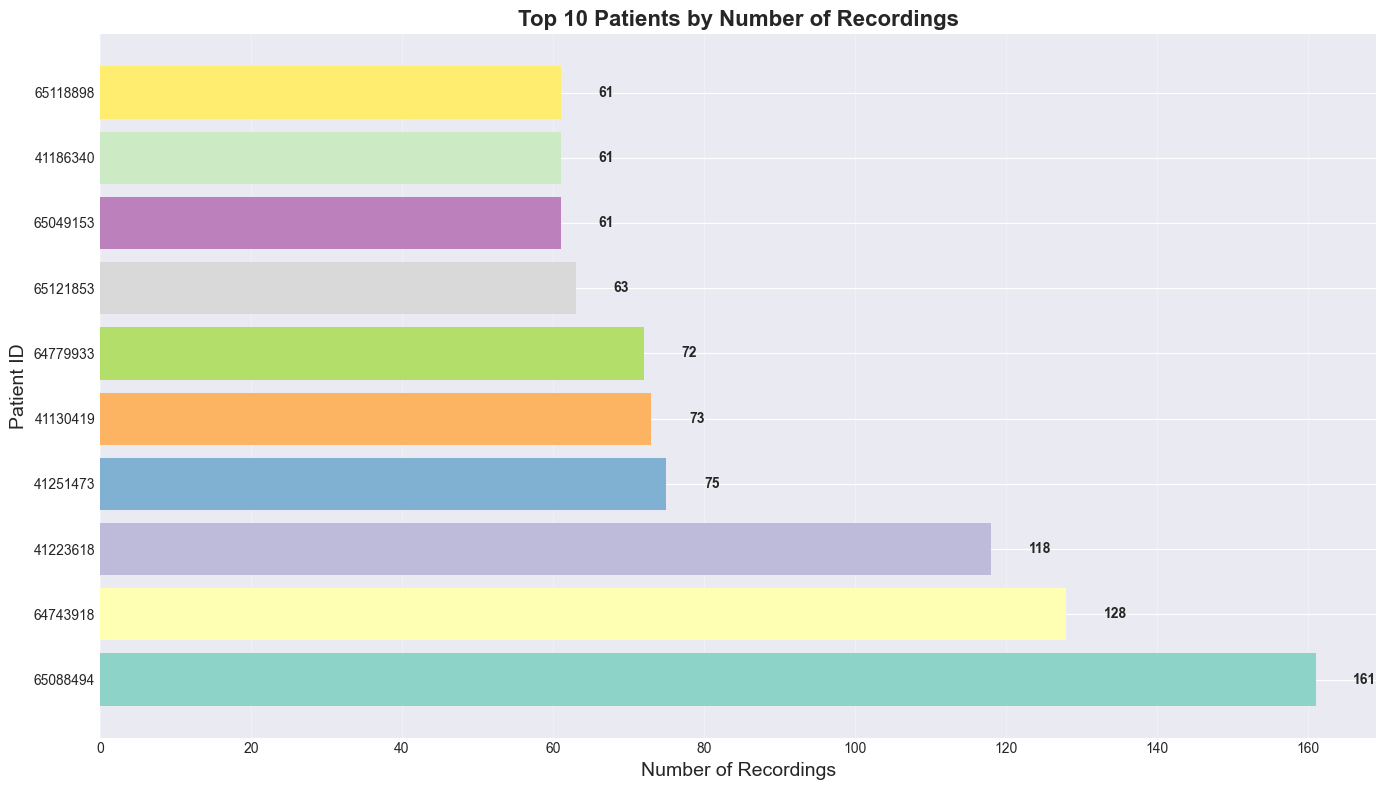


Dataset Balance Metrics:
Total patients: 868
Total recordings: 7856
Top 5 patients contribute: 7.1% of all recordings
Average recordings per patient: 9.1
Median recordings per patient: 6.0


In [144]:
print("\n" + "="*60)
print("Visualization 17: Top 10 Patients by Number of Recordings")
print("="*60)

if 'df_files' in locals() and 'patient_id' in df_files.columns:
    # Get patient counts
    patient_counts = df_files['patient_id'].value_counts().head(10)
    
    plt.figure(figsize=(14, 8))
    
    # Create horizontal bar chart
    bars = plt.barh(range(len(patient_counts)), patient_counts.values, 
                    color=plt.cm.Set3(np.linspace(0, 1, len(patient_counts))))
    
    plt.title('Top 10 Patients by Number of Recordings', fontsize=16, fontweight='bold')
    plt.xlabel('Number of Recordings', fontsize=14)
    plt.ylabel('Patient ID', fontsize=14)
    plt.yticks(range(len(patient_counts)), patient_counts.index)
    plt.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, patient_counts.values)):
        plt.text(val + 5, i, str(val), va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'sprsound22_top_patients.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Calculate imbalance metrics
    total_patients = len(df_files['patient_id'].unique())
    total_recordings = len(df_files)
    top_5_pct = patient_counts.head(5).sum() / total_recordings * 100
    
    print(f"\nDataset Balance Metrics:")
    print(f"Total patients: {total_patients}")
    print(f"Total recordings: {total_recordings}")
    print(f"Top 5 patients contribute: {top_5_pct:.1f}% of all recordings")
    print(f"Average recordings per patient: {total_recordings/total_patients:.1f}")
    print(f"Median recordings per patient: {df_files['patient_id'].value_counts().median():.1f}")
else:
    print("Need patient ID information")

### Visualization 18 - Enhanced Event Duration Distribution


Visualization 18: Enhanced Event Duration Distribution by Symptom Class


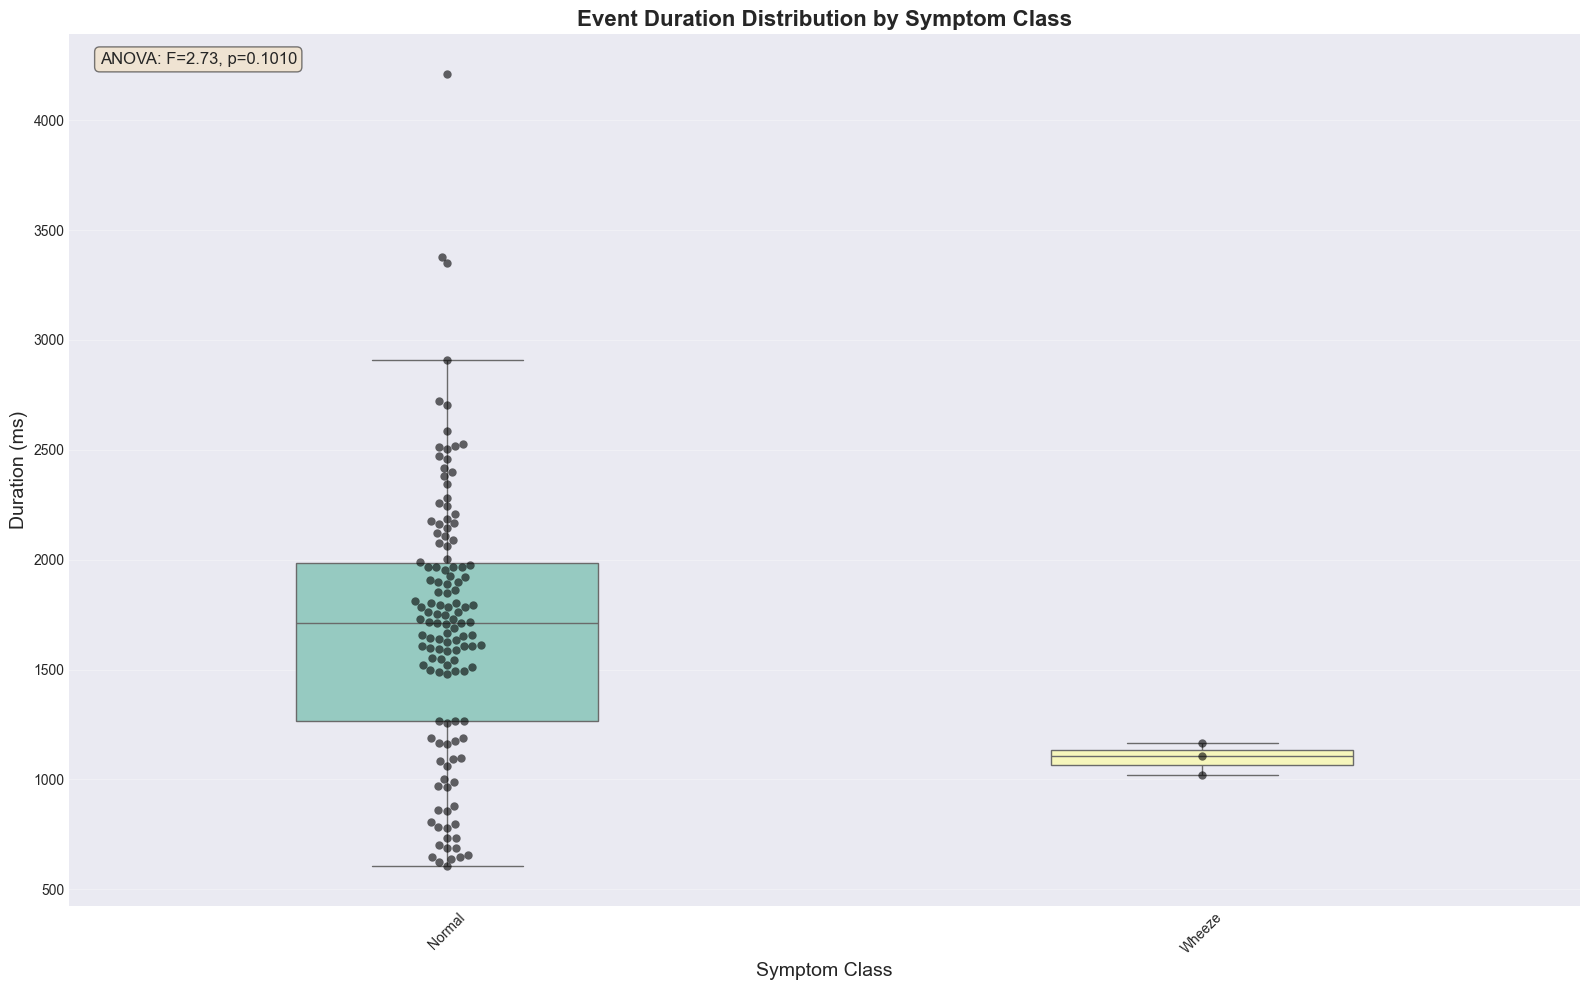


Detailed Duration Statistics by Symptom Class:
               count     mean     std     min     q25  median      q75  \
symptom_class                                                            
Normal           130  1688.64  617.78   606.0  1266.5  1711.0  1985.25   
Wheeze             3  1097.33   71.99  1021.0  1064.0  1107.0  1135.50   

                  max     iqr  
symptom_class                  
Normal         4210.0  718.75  
Wheeze         1164.0   71.50  

With Coefficient of Variation:
               count     mean     std  cv (%)  median     iqr
symptom_class                                                
Normal           130  1688.64  617.78   36.58  1711.0  718.75
Wheeze             3  1097.33   71.99    6.56  1107.0   71.50


In [145]:
print("\n" + "="*60)
print("Visualization 18: Enhanced Event Duration Distribution by Symptom Class")
print("="*60)

if 'df_events' in locals() and len(df_events) > 0:
    if 'symptom_class' in df_events.columns and 'duration_ms' in df_events.columns:
        plt.figure(figsize=(16, 10))
        
        # Create boxplot with swarm overlay
        ax = sns.boxplot(data=df_events, x='symptom_class', y='duration_ms', 
                        palette='Set3', width=0.4, showfliers=False)
        
        # Add swarm plot for individual points
        sns.swarmplot(data=df_events, x='symptom_class', y='duration_ms', 
                     color='black', size=6, alpha=0.6)
        
        plt.title('Event Duration Distribution by Symptom Class', fontsize=16, fontweight='bold')
        plt.xlabel('Symptom Class', fontsize=14)
        plt.ylabel('Duration (ms)', fontsize=14)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        
        # Add statistical annotations
        from scipy import stats
        
        # Get unique classes
        classes = df_events['symptom_class'].unique()
        if len(classes) >= 2:
            # Perform ANOVA
            groups = [df_events[df_events['symptom_class'] == c]['duration_ms'].values for c in classes if len(df_events[df_events['symptom_class'] == c]) > 0]
            if len(groups) >= 2:
                f_stat, p_val = stats.f_oneway(*groups)
                
                # Add text annotation
                plt.text(0.02, 0.98, f'ANOVA: F={f_stat:.2f}, p={p_val:.4f}', 
                        transform=plt.gca().transAxes, fontsize=12,
                        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.savefig(figures_dir / 'sprsound23_enhanced_duration_by_symptom.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Print detailed statistics
        print("\n" + "="*60)
        print("Detailed Duration Statistics by Symptom Class:")
        print("="*60)
        stats_df = df_events.groupby('symptom_class')['duration_ms'].agg([
            'count', 'mean', 'std', 'min', 
            ('q25', lambda x: x.quantile(0.25)),
            'median',
            ('q75', lambda x: x.quantile(0.75)),
            'max',
            ('iqr', lambda x: x.quantile(0.75) - x.quantile(0.25))
        ]).round(2)
        print(stats_df)
        
        # Add coefficient of variation
        stats_df['cv (%)'] = (stats_df['std'] / stats_df['mean'] * 100).round(2)
        print("\nWith Coefficient of Variation:")
        print(stats_df[['count', 'mean', 'std', 'cv (%)', 'median', 'iqr']])
        
    else:
        print("Missing required columns: symptom_class or duration_ms")
else:
    print("Need event data for this visualization")

###  Visualization 19 - Audio Feature Radar Chart by Symptom Class

In [146]:
print("\n" + "="*60)
print("Visualization 19: Audio Feature Radar Chart by Symptom Class")
print("="*60)

if 'df_events' in locals() and len(df_events) > 0 and 'df_audio' in locals() and len(df_audio) > 0:
    # Merge audio features with events
    if 'recording_file' in df_events.columns and 'file' in df_audio.columns:
        df_audio_with_labels = pd.merge(
            df_audio, 
            df_events[['recording_file', 'symptom_class']].drop_duplicates(),
            left_on='file', 
            right_on='recording_file',
            how='inner'
        )
        
        if len(df_audio_with_labels) > 0:
            # Select features for radar chart
            feature_cols = ['rms_mean', 'zcr_mean', 'spectral_centroid']
            feature_cols = [col for col in feature_cols if col in df_audio_with_labels.columns]
            mfcc_cols = [f'mfcc_{i+1}' for i in range(5) if f'mfcc_{i+1}' in df_audio_with_labels.columns]
            feature_cols.extend(mfcc_cols[:3])  # Use first 3 MFCCs
            
            if len(feature_cols) >= 4:
                # Normalize features for radar chart
                from sklearn.preprocessing import MinMaxScaler
                
                # Group by symptom class and calculate means
                class_means = df_audio_with_labels.groupby('symptom_class')[feature_cols].mean()
                
                # Normalize
                scaler = MinMaxScaler()
                normalized = pd.DataFrame(
                    scaler.fit_transform(class_means.T).T,
                    columns=class_means.columns,
                    index=class_means.index
                )
                
                # Set up radar chart
                categories = feature_cols
                N = len(categories)
                angles = [n / float(N) * 2 * np.pi for n in range(N)]
                angles += angles[:1]  # Close the loop
                
                # Create figure
                fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
                
                # Plot each symptom class
                colors = plt.cm.Set3(np.linspace(0, 1, len(normalized)))
                for idx, (symptom, values) in enumerate(normalized.iterrows()):
                    data = values.values.tolist()
                    data += data[:1]  # Close the loop
                    ax.plot(angles, data, 'o-', linewidth=2, label=symptom, color=colors[idx])
                    ax.fill(angles, data, alpha=0.1, color=colors[idx])
                
                # Set category labels
                ax.set_xticks(angles[:-1])
                ax.set_xticklabels(categories, size=10)
                
                # Add legend and title
                plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
                plt.title('Audio Feature Profiles by Symptom Class', size=16, fontweight='bold', pad=20)
                
                plt.tight_layout()
                plt.savefig(figures_dir / 'sprsound24_feature_radar.png', dpi=150, bbox_inches='tight')
                plt.show()
                
                print("\nNormalized Feature Values by Symptom Class:")
                print(normalized.round(3))
            else:
                print(f"Not enough features for radar chart. Found: {feature_cols}")
    else:
        print("Missing required columns")
else:
    print("Need both event labels and audio features for this visualization")


Visualization 19: Audio Feature Radar Chart by Symptom Class


## 11. Visualizations_4

### Visualization 20: Recordings per Patient


Visualization 20:Recordings per Patient


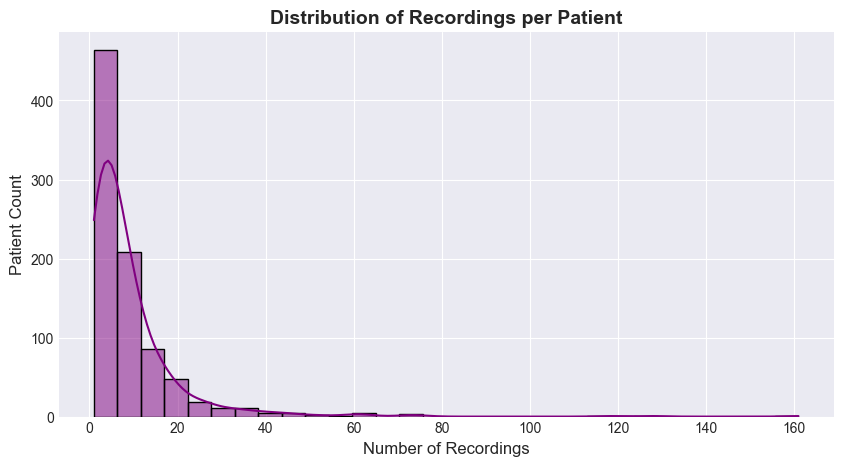

Max recordings for a single patient: 161
Mean recordings per patient: 9.05


In [147]:
print("\n" + "="*60)
print("Visualization 20:Recordings per Patient")
print("="*60)

plt.figure(figsize=(10, 5))
recordings_per_patient = df_files['patient_id'].value_counts()
sns.histplot(recordings_per_patient, bins=30, kde=True, color='purple')
plt.title('Distribution of Recordings per Patient', fontsize=14, fontweight='bold')
plt.xlabel('Number of Recordings', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)
plt.show()

print(f"Max recordings for a single patient: {recordings_per_patient.max()}")
print(f"Mean recordings per patient: {recordings_per_patient.mean():.2f}")

### Visualization 21: Recording Location Significance


Visualization 21: Recording Location Significance


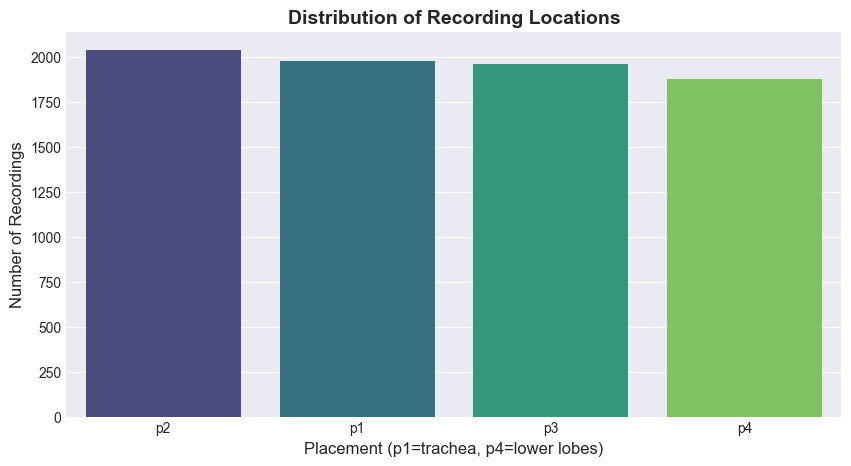

In [148]:
print("\n" + "="*60)
print("Visualization 21: Recording Location Significance")
print("="*60)

plt.figure(figsize=(10, 5))
location_counts = df_files['location'].value_counts()
sns.barplot(x=location_counts.index, y=location_counts.values, palette='viridis')
plt.title('Distribution of Recording Locations', fontsize=14, fontweight='bold')
plt.xlabel('Placement (p1=trachea, p4=lower lobes)', fontsize=12)
plt.ylabel('Number of Recordings', fontsize=12)
plt.show()


### Visualization 22: Acoustic Quality Comparison


Visualization 22: Acoustic Quality Comparison


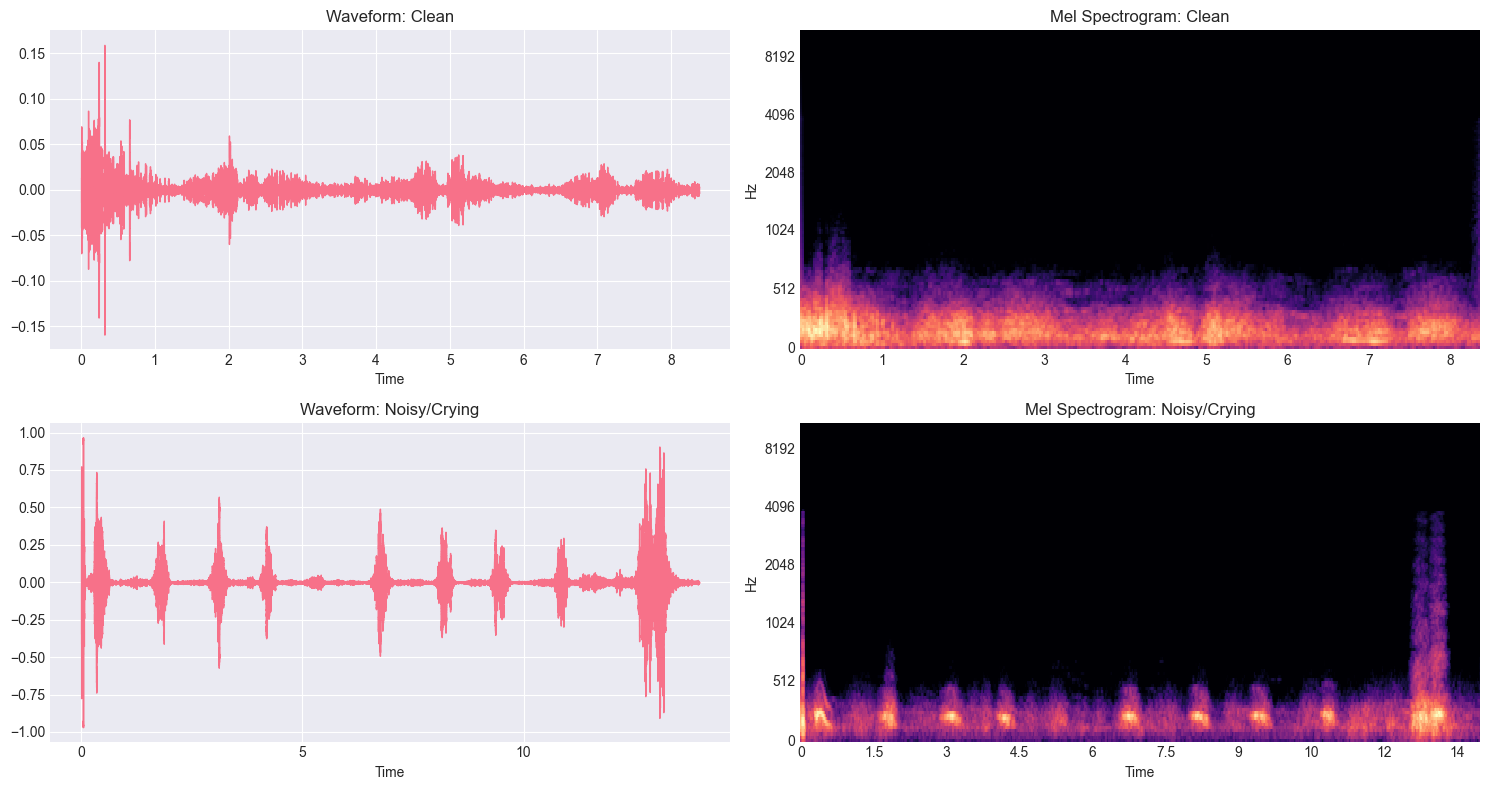

In [149]:
print("\n" + "="*60)
print("Visualization 22: Acoustic Quality Comparison")
print("="*60)

def plot_audio_comparison(file_path_clean, file_path_noisy):
    fig, ax = plt.subplots(2, 2, figsize=(15, 8))
    
    for i, path in enumerate([file_path_clean, file_path_noisy]):
        y, sr = librosa.load(path)
        # Waveform
        librosa.display.waveshow(y, sr=sr, ax=ax[i, 0])
        ax[i, 0].set_title(f'Waveform: {"Clean" if i==0 else "Noisy/Crying"}')
        
        # Mel Spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr)
        S_db = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_db, x_axis='time', y_axis='mel', ax=ax[i, 1])
        ax[i, 1].set_title(f'Mel Spectrogram: {"Clean" if i==0 else "Noisy/Crying"}')
    
    plt.tight_layout()
    plt.show()

plot_audio_comparison(df_files.iloc[0]['full_path'], df_files.iloc[10]['full_path'])

### Visualization 23: Age Groups 


Visualization 23: Age Groups Identified


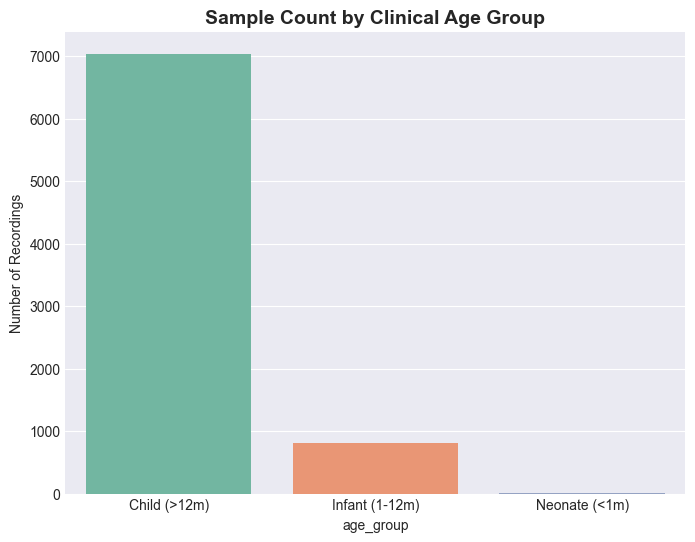


Age Group Counts:
age_group
Child (>12m)      7041
Infant (1-12m)     811
Neonate (<1m)        4
Name: count, dtype: int64


In [150]:
print("\n" + "="*60)
print("Visualization 23: Age Groups Identified")
print("="*60)

def age_category(months):
    if months <= 1: return 'Neonate (<1m)'
    elif months <= 12: return 'Infant (1-12m)'
    else: return 'Child (>12m)'

# age_months was created in your Visualization 1 cell
df_files['age_group'] = df_files['age_months'].apply(age_category)

plt.figure(figsize=(8, 6))
sns.countplot(data=df_files, x='age_group', palette='Set2')
plt.title('Sample Count by Clinical Age Group', fontsize=14, fontweight='bold')
plt.ylabel('Number of Recordings')
plt.show()

print("\nAge Group Counts:")
print(df_files['age_group'].value_counts())

## 12. Complete Summary

In [151]:
print("\n" + "="*60)
print("SPRSOUND DATASET - COMPLETE SUMMARY")
print("="*60)

# File counts
total_wav = len(wav_files)
total_json = len(json_files)

# Patient statistics
unique_patients = df_files['patient_id'].nunique() if 'df_files' in locals() else 0
age_range = f"{df_files['age'].min():.1f} - {df_files['age'].max():.1f} years" if 'df_files' in locals() else 'N/A'

# Gender distribution
if 'df_files' in locals() and 'gender' in df_files.columns:
    gender_counts = df_files['gender'].value_counts()
    gender_str = f"M: {gender_counts.get('Male', 0)}, F: {gender_counts.get('Female', 0)}"
else:
    gender_str = 'N/A'

# Location distribution
if 'df_files' in locals() and 'location' in df_files.columns:
    locations = ', '.join(df_files['location'].unique())
else:
    locations = 'N/A'

# Year distribution
if 'df_files' in locals() and 'year' in df_files.columns:
    years = ', '.join(df_files['year'].unique())
else:
    years = 'N/A'

# Split distribution
if 'df_files' in locals() and 'split' in df_files.columns:
    split_counts = df_files['split'].value_counts()
    split_str = f"Train: {split_counts.get('train', 0)}, Test: {split_counts.get('test', 0)}"
else:
    split_str = 'N/A'

# Event statistics
if len(df_events) > 0:
    total_events = len(df_events)
    unique_event_types = df_events['event_type'].nunique()
    event_types_list = ', '.join(df_events['event_type'].unique())
else:
    total_events = 0
    unique_event_types = 0
    event_types_list = 'N/A'

# Create summary dataframe
summary = pd.DataFrame({
    'Metric': [
        'Total Audio Files',
        'Total JSON Files',
        'Unique Patients',
        'Age Range',
        'Gender Distribution',
        'Recording Locations',
        'Years Included',
        'Train/Test Split',
        'Total Events Parsed',
        'Unique Event Types',
        'Event Types'
    ],
    'Value': [
        total_wav,
        total_json,
        unique_patients,
        age_range,
        gender_str,
        locations,
        years,
        split_str,
        total_events,
        unique_event_types,
        event_types_list
    ]
})

print("\n", summary.to_string(index=False))

# Save summary
summary.to_csv(SPRSound_PATH / "sprsound_eda_summary.csv", index=False)
if 'df_files' in locals():
    df_files.to_csv(SPRSound_PATH / "sprsound_file_list.csv", index=False)

print(f"\n All visualizations saved to: {figures_dir}")
print(f" Summaries saved to: {SPRSound_PATH}/sprsound_eda_summary.csv")


SPRSOUND DATASET - COMPLETE SUMMARY

              Metric                   Value
  Total Audio Files                    8246
   Total JSON Files                    6567
    Unique Patients                     868
          Age Range        0.0 - 55.0 years
Gender Distribution              M: 0, F: 0
Recording Locations          p4, p2, p3, p1
     Years Included           unknown, test
   Train/Test Split Train: 3628, Test: 4228
Total Events Parsed                     133
 Unique Event Types                       2
        Event Types          Normal, Wheeze

 All visualizations saved to: ..\reports\figures\sprsound
 Summaries saved to: ..\..\sound_data\sprsound/sprsound_eda_summary.csv


## 13. Prepare Data for Modeling

In [152]:
def prepare_for_modeling(df_files, df_events):
    # Prepare SPRSound data for model training
    # Creates a feature matrix with one row per recording
    print("\n" + "="*60)
    print("PREPARING DATA FOR MODELING")
    print("="*60)
    
    # Start with file metadata
    recording_features = df_files.copy()
    
    # Create a unique recording key
    if 'filename' in recording_features.columns:
        recording_features['recording_key'] = recording_features['filename']
    else:
        recording_features['recording_key'] = recording_features['file']
    
    # Aggregate event info per recording
    if len(df_events) > 0:
        print(f"\nProcessing {len(df_events)} events from {df_events['recording_file'].nunique() if 'recording_file' in df_events.columns else 0} recordings...")
        
        # Check what columns we have
        print(f"df_events columns: {df_events.columns.tolist()}")
        
        if 'recording_file' in df_events.columns:
            # Group by recording_file
            event_stats = df_events.groupby('recording_file').agg({
                'duration_ms': ['count', 'mean', 'sum'],
                'event_type': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
            }).reset_index()
            
            # Flatten column names
            event_stats.columns = ['recording_file', 'event_count', 'avg_event_duration', 
                                  'total_event_duration', 'primary_event_type']
            
            print(f"Created event statistics for {len(event_stats)} recordings")
            
            # Merge with recording features
            recording_features = recording_features.merge(
                event_stats, 
                left_on='recording_key', 
                right_on='recording_file', 
                how='left'
            )
        else:
            print("'recording_file' column not found in df_events")
    else:
        print("No event data available")
    
    # Fill NaN values
    for col in ['event_count', 'avg_event_duration', 'total_event_duration']:
        if col in recording_features.columns:
            recording_features[col] = recording_features[col].fillna(0)
    
    if 'primary_event_type' in recording_features.columns:
        recording_features['primary_event_type'] = recording_features['primary_event_type'].fillna('Unknown')
    
    print(f"\nFinal feature matrix shape: {recording_features.shape}")
    print(f"Columns: {recording_features.columns.tolist()}")
    
    return recording_features

# Prepare data
if 'df_files' in locals():
    model_ready_df = prepare_for_modeling(df_files, df_events if 'df_events' in locals() else pd.DataFrame())
    
    # Save to CSV
    model_ready_df.to_csv(sprsound_path / "sprsound_model_ready.csv", index=False)
    print(f"\nModel-ready data saved to: {sprsound_path / 'sprsound_model_ready.csv'}")
    
    # Show summary
    print("\nData Summary for Modeling:")
    print(f"Total recordings: {len(model_ready_df)}")
    if 'primary_event_type' in model_ready_df.columns:
        print("\nPrimary event type distribution:")
        print(model_ready_df['primary_event_type'].value_counts())
else:
    print("df_files not available")


PREPARING DATA FOR MODELING

Processing 133 events from 45 recordings...
df_events columns: ['annotation_file', 'recording_file', 'start_ms', 'end_ms', 'duration_ms', 'event_type', 'symptom_class', 'duration_sec']
Created event statistics for 45 recordings

Final feature matrix shape: (7856, 18)
Columns: ['filename', 'patient_id', 'age', 'gender', 'location', 'recording_id', 'year', 'split', 'full_path', 'actual_symptom', 'age_months', 'age_group', 'recording_key', 'recording_file', 'event_count', 'avg_event_duration', 'total_event_duration', 'primary_event_type']


NameError: name 'sprsound_path' is not defined